# Прогноз ущерба от ДТП (damage) - полный пайплайн

## Часть 1. Разведочный анализ данных (EDA)

Контекст. Клиент предоставил датасет городских ДТП: условия на момент аварии (погода, освещённость,
состояние дороги), характеристики дорожной инфраструктуры, тип регулирования движения, временной контекст
и итоговые последствия каждого инцидента (травмы, тип столкновения, причина).

Задача. Оценить ущерб от аварии - целевая переменная `damage`, категориальный признак с тремя уровнями:
`$500 OR LESS`, `$501 - $1,500`, `OVER $1,500`. Это задача многоклассовой классификации с естественным
порядком классов (чем дальше категория, тем крупнее ущерб).

Единый ноутбук состоит из трёх частей: 1) EDA, 2) предобработка и feature engineering, 3) модели, тюнинг, блендинг и интерпретация. Каждая часть - самостоятельный раздел с одинаковым подходом: что попробовали -> что сработало / что нет -> почему -> что оставляем дальше.

План Части 1 (EDA):
1. Загрузка и первичный осмотр данных
2. Пропуски и их скрытые формы (не всегда `NaN`)
3. Дубликаты
4. Целевая переменная и дисбаланс классов
5. Univariate-анализ (числовые и категориальные признаки)
6. Мультиколлинеарность и корреляции
7. Bivariate-анализ (признаки vs `damage`)
8. Временная динамика
9. Статистические тесты связи признаков с target
10. Итоговые инсайты - что переносим в ноутбук предобработки

Все выводы, сделанные здесь, пояснены в markdown-ячейках: *что увидели → почему это важно → что с этим
делаем дальше*.


## 1. Загрузка и первичный осмотр

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42


Особенность файла. Исходный CSV пришёл с каждой строкой, обёрнутой во внешние двойные кавычки
(артефакт экспорта из Google Sheets/аналогичного инструмента) - если прочитать его `pd.read_csv` напрямую,
все 24 столбца схлопнутся в один. Поэтому сначала снимаем внешнее экранирование построчно, а затем уже
парсим как обычный CSV.

In [2]:
import csv, io

RAW_PATH = '../data/crashes_raw.csv'

with open(RAW_PATH, newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    rows = list(reader)

# each row was one quoted field - csv.reader already stripped the outer quoting
# and unescaped doubled quotes inside, e.g. "$1,500" in the damage field
inner_csv = '\n'.join(row[0] for row in rows)
df = pd.read_csv(io.StringIO(inner_csv))

print(f'Строк: {df.shape[0]}, столбцов: {df.shape[1]}')
df.head(3)


Строк: 9573, столбцов: 24


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,intersection_related_i,damage,prim_contributory_cause,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",UNABLE TO DETERMINE,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,"OVER $1,500",IMPROPER TURNING/NO SIGNAL,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",FOLLOWING TOO CLOSELY,3,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9573 entries, 0 to 9572
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   crash_date                     9573 non-null   str    
 1   traffic_control_device         9573 non-null   str    
 2   weather_condition              9573 non-null   str    
 3   lighting_condition             9573 non-null   str    
 4   first_crash_type               9573 non-null   str    
 5   trafficway_type                9573 non-null   str    
 6   alignment                      9573 non-null   str    
 7   roadway_surface_cond           9573 non-null   str    
 8   road_defect                    9573 non-null   str    
 9   crash_type                     9573 non-null   str    
 10  intersection_related_i         9573 non-null   str    
 11  damage                         9573 non-null   str    
 12  prim_contributory_cause        9573 non-null   str    
 13 

Наблюдение. `pandas` не находит ни одного `NaN` - по `.info()` все 24 столбца заполнены на 100%.
Это не значит, что пропусков нет: в датасетах дорожной полиции (в т.ч. в оригинальном Chicago Traffic
Crashes, на структуру которого похож этот датасет) отсутствие информации почти всегда кодируется явным
текстом - `UNKNOWN`, `NOT APPLICABLE`, `OTHER` - а не пустым значением. Проверяем это в следующем разделе.

## 2. Пропуски - и почему `isna()` их не видит

Ищем во всех категориальных столбцах "sentinel"-значения, которые по смыслу являются пропуском:
`UNKNOWN`, `UNABLE TO DETERMINE`, `NOT APPLICABLE`, `NOT REPORTED`.
`OTHER` не считаем пропуском - это содержательная категория ("причина есть, но не входит в список"),
а не отсутствие данных.

In [4]:
MISSING_TOKENS = {'UNKNOWN', 'UNABLE TO DETERMINE', 'NOT APPLICABLE', 'NOT REPORTED'}

cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('crash_date')  # it's a date, not a category

missing_report = []
for c in cat_cols:
    n_missing = df[c].isin(MISSING_TOKENS).sum()
    missing_report.append({'column': c, 'true_nan': df[c].isna().sum(),
                            'sentinel_missing': n_missing,
                            'sentinel_pct': round(n_missing / len(df) * 100, 1)})

missing_df = pd.DataFrame(missing_report).sort_values('sentinel_pct', ascending=False)
missing_df


/tmp/ipykernel_1752/428398852.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


,column,true_nan,sentinel_missing,sentinel_pct
11,prim_contributory_cause,0,2963,31.0
7,road_defect,0,1565,16.3
6,roadway_surface_cond,0,586,6.1
1,weather_condition,0,296,3.1
0,traffic_control_device,0,236,2.5
2,lighting_condition,0,189,2.0
4,trafficway_type,0,81,0.8
3,first_crash_type,0,0,0.0
5,alignment,0,0,0.0
8,crash_type,0,0,0.0


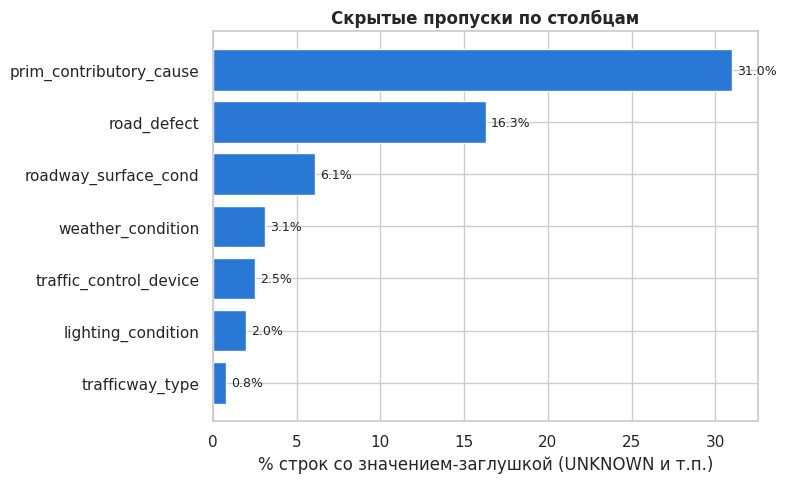

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = missing_df[missing_df['sentinel_pct'] > 0].sort_values('sentinel_pct')
ax.barh(plot_df['column'], plot_df['sentinel_pct'], color='#2a78d6')
ax.set_xlabel('% строк со значением-заглушкой (UNKNOWN и т.п.)')
ax.set_title('Скрытые пропуски по столбцам')
for i, v in enumerate(plot_df['sentinel_pct']):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


Итог. Значимые доли "скрытых" пропусков - в `prim_contributory_cause` (31%: `UNABLE TO DETERMINE` +
`NOT APPLICABLE`), `road_defect` (17%), `roadway_surface_cond` (6%), остальные - единицы процентов.
31% в причине ДТП - это не случайный шум, а системная особенность (полиция часто не может установить точную
причину на месте), поэтому в предобработке разумнее не выбрасывать эти строки, а трактовать `UNKNOWN`/
`UNABLE TO DETERMINE` как самостоятельную категорию ("причина не установлена" - само по себе информативно),
а не пытаться её импutировать модой.

Также стоит проверить, не связаны ли пропуски друг с другом (паттерн MNAR/MAR) - например, не пропускает ли
полиция сразу несколько полей в одном и том же типе инцидентов.

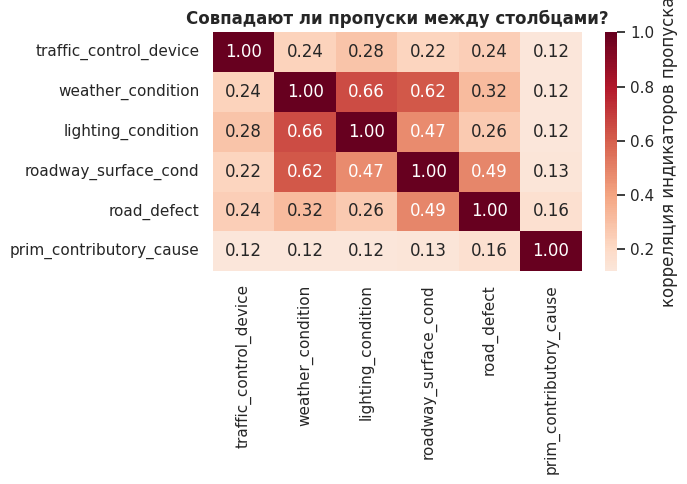

In [6]:
# do missing values in different columns line up with each other?
missing_matrix = pd.DataFrame({c: df[c].isin(MISSING_TOKENS) for c in cat_cols if missing_df.set_index('column').loc[c, 'sentinel_pct'] > 1})

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(missing_matrix.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'корреляция индикаторов пропуска'})
ax.set_title('Совпадают ли пропуски между столбцами?')
plt.tight_layout()
plt.show()


Заметной корреляции между индикаторами пропуска нет (кроме слабой связи `road_defect` /
`roadway_surface_cond` - логично, оба поля про физическое состояние дороги и их, вероятно, заполняет один
и тот же участок протокола). Значит, отдельного MNAR-паттерна, требующего специальной обработки, нет - 
можно обрабатывать столбцы независимо.

## 3. Дубликаты

In [7]:
print('Полные дубликаты строк:', df.duplicated().sum())
print('Дубликаты без учёта crash_date:', df.drop(columns=['crash_date']).duplicated().sum())


Полные дубликаты строк: 0
Дубликаты без учёта crash_date: 8


Дубликатов нет ни в полном виде, ни без даты - каждая запись уникальна. Пункт чек-листа закрыт без
дополнительных действий.

## 4. Целевая переменная - `damage`

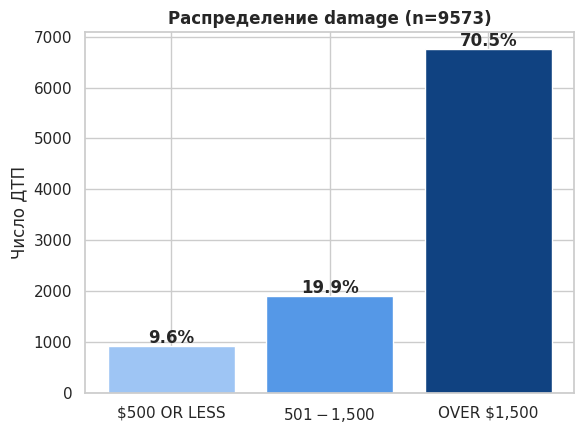

damage
$500 OR LESS     0.096
$501 - $1,500    0.199
OVER $1,500      0.705
Name: proportion, dtype: float64

In [8]:
target_counts = df['damage'].value_counts()
target_share = df['damage'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(6, 4.5))
order = ['$500 OR LESS', '$501 - $1,500', 'OVER $1,500']
colors = ['#9ec5f4', '#5598e7', '#104281']
bars = ax.bar(order, target_counts.reindex(order), color=colors)
for b, pct in zip(bars, target_share.reindex(order)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 60, f'{pct*100:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Число ДТП')
ax.set_title(f'Распределение damage (n={len(df)})')
plt.tight_layout()
plt.show()

target_share.reindex(order).round(3)


Сильный дисбаланс классов: `OVER $1,500` - 70.5%, `$501-$1,500` - 19.9%, `$500 OR LESS` - 9.6%.
Соотношение мажоритарного к минимальному классу - почти 7:1.

Последствия для дальнейшей работы:
- accuracy - плохая метрика сама по себе: константный прогноз "всегда OVER $1,500" уже даст ~70.5%
  точности, ничего не предсказывая. Нужны macro/weighted F1, per-class precision/recall, confusion matrix.
- Стоит попробовать class balancing (SMOTE и его варианты - библиотека `crucio`) на этапе
  предобработки и сравнить с моделями, обученными без балансировки и/или через `class_weight='balanced'`.
- Разбиение на train/val/test должно быть стратифицированным по `damage`.


## 5. Числовые признаки - Univariate

In [9]:
num_cols = ['num_units', 'injuries_total', 'injuries_fatal', 'injuries_incapacitating',
            'injuries_non_incapacitating', 'injuries_reported_not_evident', 'injuries_no_indication',
            'crash_hour', 'crash_day_of_week', 'crash_month']
df[num_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
num_units,9573.0,2.06,0.38,1.0,2.0,2.0,2.0,8.0
injuries_total,9573.0,0.37,0.76,0.0,0.0,0.0,1.0,11.0
injuries_fatal,9573.0,0.00,0.04,0.0,0.0,0.0,0.0,2.0
injuries_incapacitating,9573.0,0.04,0.23,0.0,0.0,0.0,0.0,5.0
injuries_non_incapacitating,9573.0,0.22,0.60,0.0,0.0,0.0,0.0,10.0
injuries_reported_not_evident,9573.0,0.11,0.41,0.0,0.0,0.0,0.0,6.0
injuries_no_indication,9573.0,2.24,1.17,0.0,2.0,2.0,3.0,20.0
crash_hour,9573.0,13.29,5.60,0.0,9.0,14.0,17.0,23.0
crash_day_of_week,9573.0,4.13,1.98,1.0,2.0,4.0,6.0,7.0
crash_month,9573.0,6.59,3.43,1.0,4.0,7.0,10.0,12.0


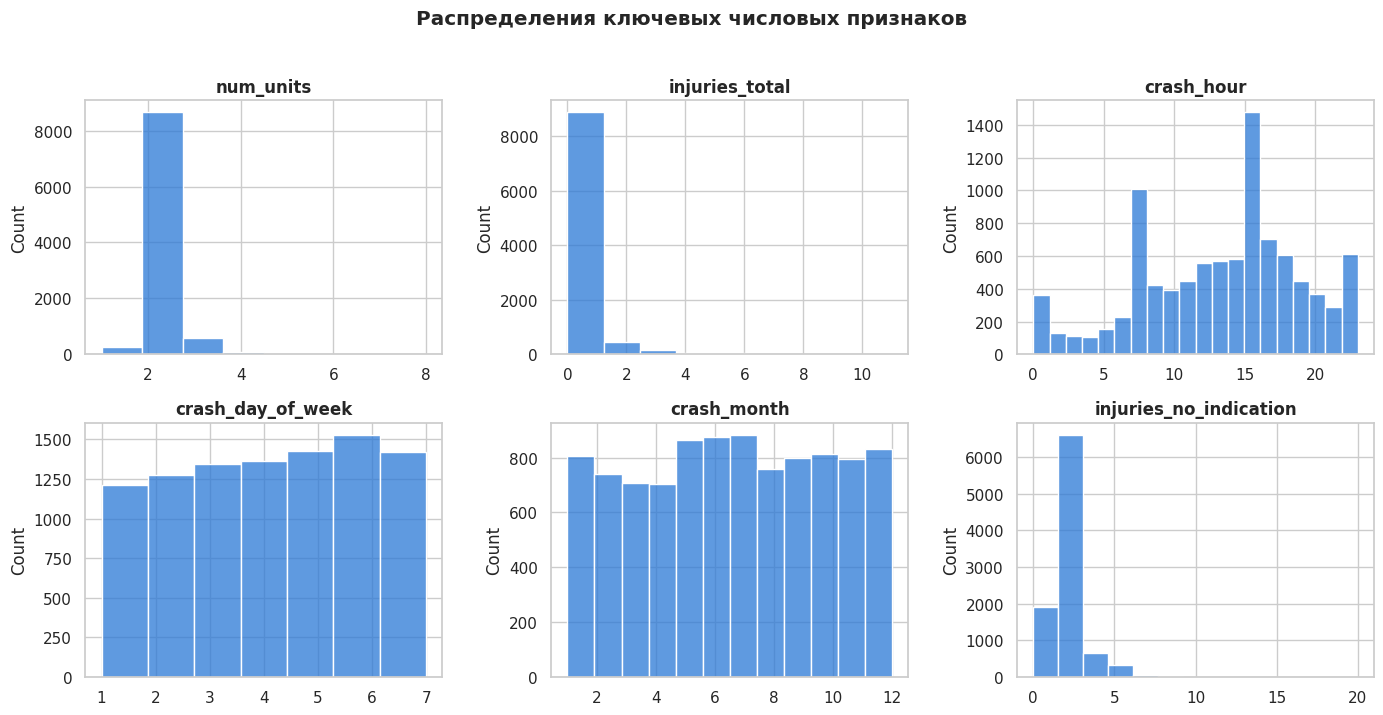

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
plot_cols = ['num_units', 'injuries_total', 'crash_hour', 'crash_day_of_week', 'crash_month', 'injuries_no_indication']
for ax, c in zip(axes.flat, plot_cols):
    sns.histplot(df[c], bins=min(20, df[c].nunique()), ax=ax, color='#2a78d6', edgecolor='white')
    ax.set_title(c)
    ax.set_xlabel('')
plt.suptitle('Распределения ключевых числовых признаков', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


Наблюдения:
- `num_units` (число участников) сосредоточено вокруг 2 - типичное столкновение двух ТС; хвост до 8 редкий.
- `injuries_total` сильно скошено к нулю (медиана 0) - большинство ДТП без пострадавших.
- `crash_hour` - два выраженных пика: утренний (~7-9ч) и особенно вечерний час пик (~15-17ч), минимум - 
  глубокая ночь.
- `crash_day_of_week`, `crash_month` - распределены заметно более равномерно.


## 6. Категориальные признаки - Univariate

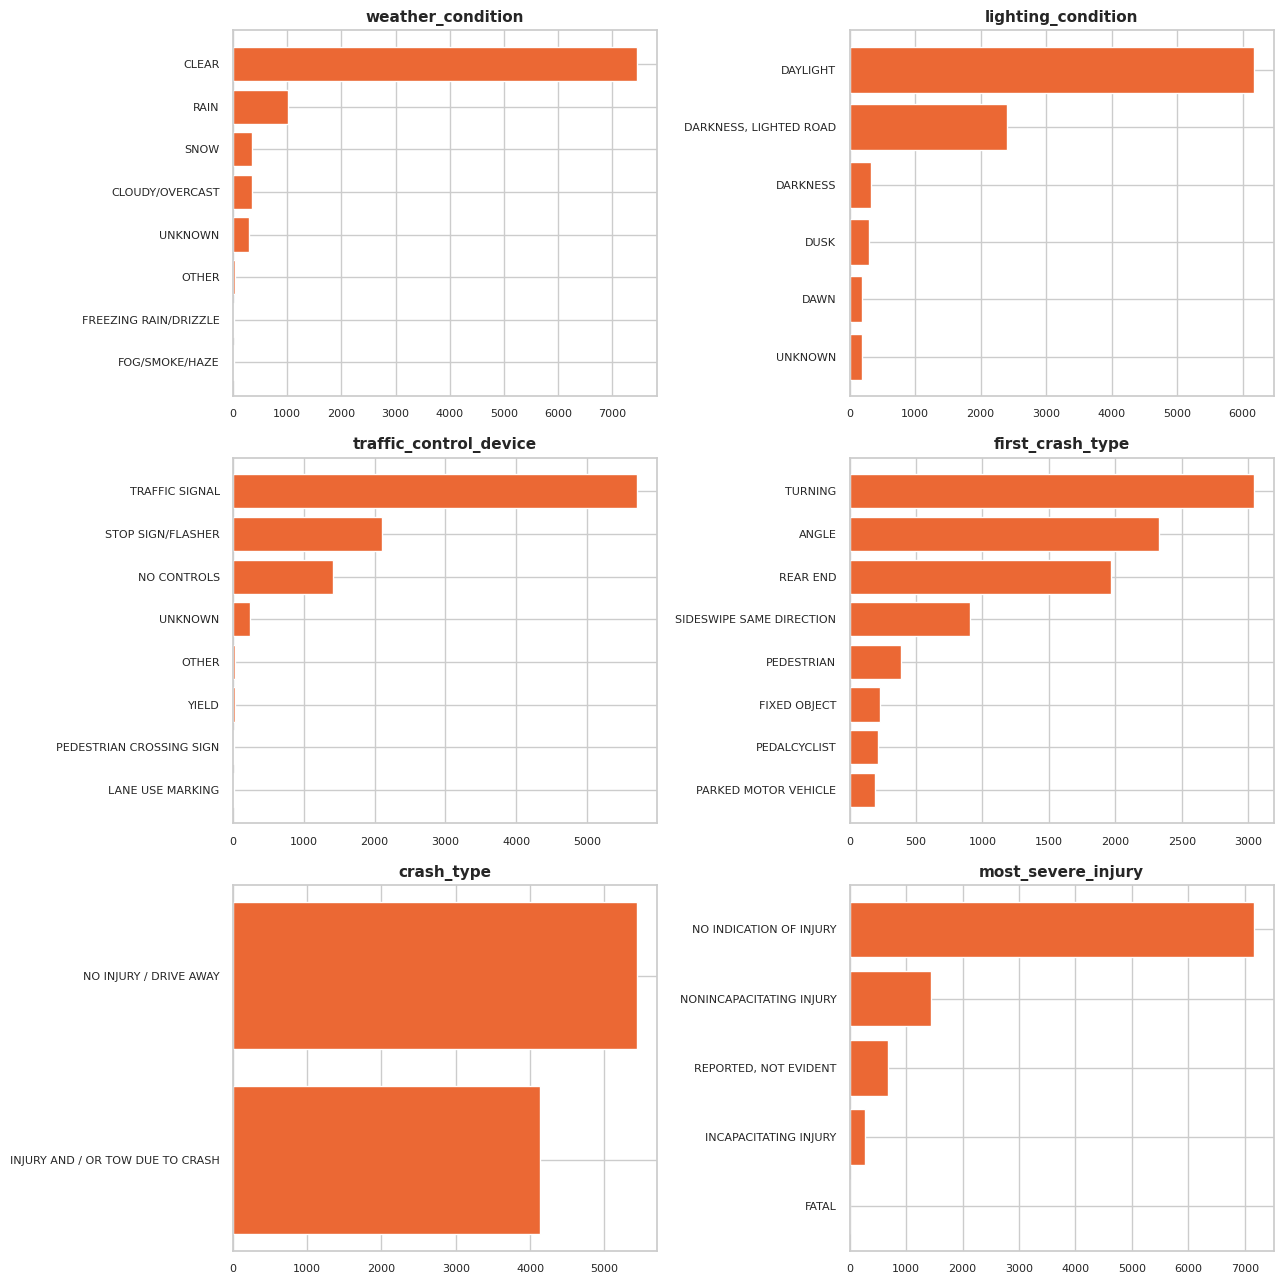

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
cat_plot_cols = ['weather_condition', 'lighting_condition', 'traffic_control_device',
                 'first_crash_type', 'crash_type', 'most_severe_injury']
for ax, c in zip(axes.flat, cat_plot_cols):
    vc = df[c].value_counts().head(8)
    ax.barh(vc.index[::-1], vc.values[::-1], color='#eb6834')
    ax.set_title(c, fontsize=11)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


Наблюдения:
- Погода в подавляющем большинстве `CLEAR` (78%) - распределение сильно несбалансировано, редкие категории
  (`SLEET/HAIL`, `BLOWING SNOW`, `SEVERE CROSS WIND GATE`...) будут иметь единицы наблюдений - кандидаты на
  объединение в "прочее" при кодировании.
- `first_crash_type`: лидируют `TURNING`, `ANGLE`, `REAR END` - типичная городская механика столкновений на
  перекрёстках, а не трассовые ДТП.
- `most_severe_injury`: 75% - вообще без признаков травмы; `FATAL` - всего 11 случаев (0.1%) - крайне редкий
  класс, если использовать это поле как признак, категорию `FATAL` тоже стоит объединить с соседней.
- `crash_type` (травма и/или эвакуация vs без последствий) - почти 50/50, что интересно контрастирует с
  сильным перекосом самого `damage` - это разные измерения тяжести ДТП, не дублирующие друг друга напрямую.


## 7. Мультиколлинеарность и корреляции

Прежде чем считать корреляции, проверим гипотезу: `injuries_total`, скорее всего, - не независимый
признак, а сумма остальных `injuries_*`-столбцов (так устроен исходный датасет Chicago Traffic
Crashes).

In [12]:
inj_parts = ['injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_reported_not_evident']
check = (df[inj_parts].sum(axis=1) == df['injuries_total']).mean()
print(f'injuries_total == сумма 4 составляющих в {check*100:.1f}% строк')


injuries_total == сумма 4 составляющих в 100.0% строк


Подтвердилось на 100% строк. `injuries_total` - детерминированная линейная комбинация четырёх
других столбцов: `injuries_total = fatal + incapacitating + non_incapacitating + reported_not_evident`.
Это классическая структурная мультиколлинеарность - держать все пять столбцов в модели одновременно
избыточно и вредно для линейных моделей (и для интерпретации SHAP/коэффициентов). Решение, которое
применим в ноутбуке предобработки: оставить либо `injuries_total` (агрегат), либо разложение по
типам травм, но не оба сразу - сравним оба варианта по CV-метрике и выберем.

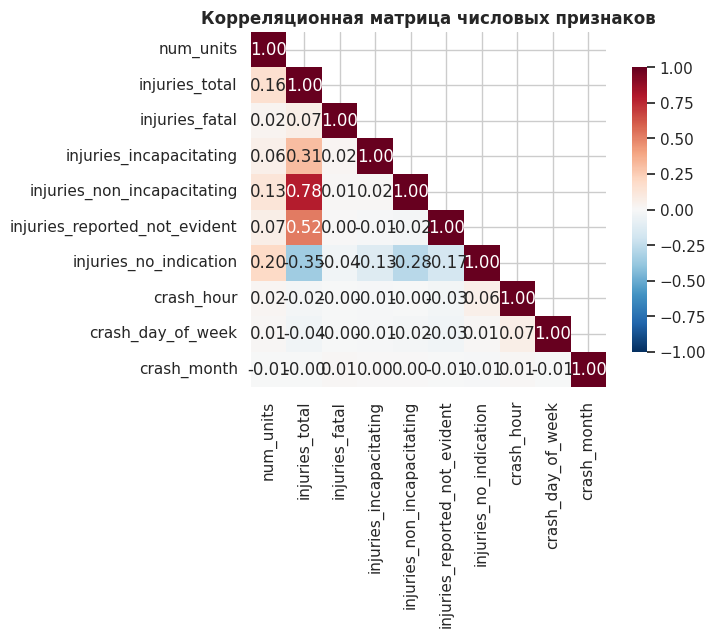

In [13]:
corr_cols = ['num_units', 'injuries_total', 'injuries_fatal', 'injuries_incapacitating',
             'injuries_non_incapacitating', 'injuries_reported_not_evident', 'injuries_no_indication',
             'crash_hour', 'crash_day_of_week', 'crash_month']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()


Вне пары `injuries_total`/составляющие - заметных линейных корреляций между числовыми признаками нет
(всё в пределах |r| < 0.35), мультиколлинеарность точечная, а не системная.

## 8. Bivariate-анализ - признаки vs `damage`

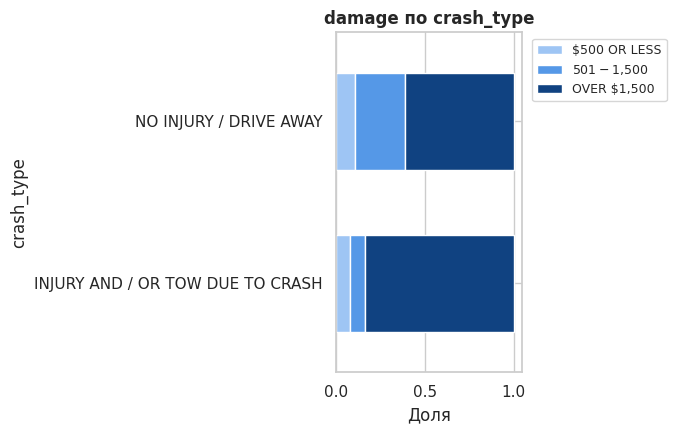

damage,$500 OR LESS,"$501 - $1,500","OVER $1,500"
crash_type,,,
INJURY AND / OR TOW DUE TO CRASH,0.081,0.086,0.833
NO INJURY / DRIVE AWAY,0.108,0.284,0.608


In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ct = pd.crosstab(df['crash_type'], df['damage'], normalize='index').reindex(columns=order)
ct.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.6)
ax.set_xlabel('Доля')
ax.set_title('damage по crash_type')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
ct.round(3)


ДТП с травмой и/или эвакуацией (`INJURY AND/OR TOW`) в 83% случаев относятся к `OVER $1,500`, тогда
как ДТП без пострадавших ("уехали сами") - только в 61%. Логичная связь: серьёзность инцидента коррелирует
и с травмами, и с ущербом одновременно (общая причина - сила удара), но это не строгая функциональная
зависимость. Важный методологический момент, который явно разберём в ноутбуке моделирования: `crash_type`,
`most_severe_injury` и `injuries_*` фиксируются постфактум, в момент того же самого протокола, что и
`damage` - это не "будущее относительно прошлого", а признаки одного уровня наблюдения. Формальной утечки
(когда target вычислим по формуле из признака) здесь нет, но это осознанный выбор - использовать их как
"сопутствующие индикаторы тяжести", а не строго причинные предикторы. Проверим в ноутбуке моделирования,
насколько сильно от них зависит качество модели.

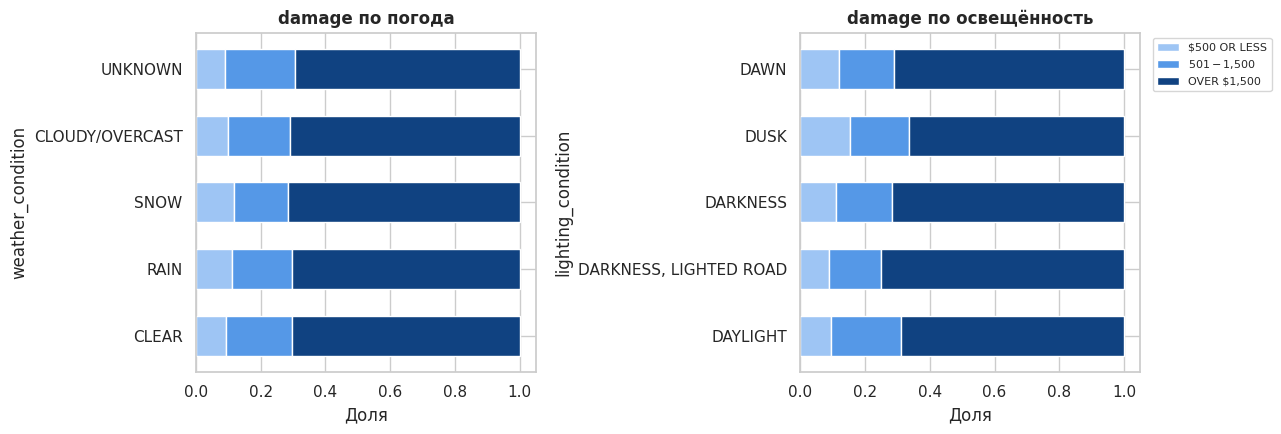

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, c, title in zip(axes, ['weather_condition', 'lighting_condition'], ['Погода', 'Освещённость']):
    top_cats = df[c].value_counts().head(5).index
    sub = df[df[c].isin(top_cats)]
    ct2 = pd.crosstab(sub[c], sub['damage'], normalize='index').reindex(columns=order).loc[top_cats]
    ct2.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.6, legend=False)
    ax.set_title(f'damage по {title.lower()}')
    ax.set_xlabel('Доля')

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


По погоде и освещённости доли `damage`-категорий визуально почти не различаются между топ-5
категориями - на глаз сильной связи не видно. Ниже это проверим формально хи-квадрат тестом, а не только
"на глаз".

/tmp/ipykernel_1752/1571327085.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='damage', y='num_units', order=order, palette=colors, ax=ax)


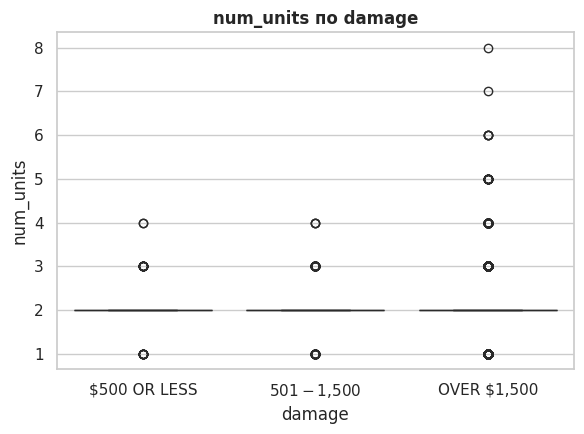

,mean,median,std
damage,,,
$500 OR LESS,2.010,2.0,0.195
"$501 - $1,500",2.007,2.0,0.229
"OVER $1,500",2.080,2.0,0.431


In [16]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x='damage', y='num_units', order=order, palette=colors, ax=ax)
ax.set_title('num_units по damage')
plt.tight_layout()
plt.show()

df.groupby('damage')['num_units'].agg(['mean', 'median', 'std']).reindex(order).round(3)


Медиана `num_units` одинакова (2) во всех трёх классах, средние различаются на сотые - как отдельный
признак `num_units` слабо разделяет классы `damage`. Это не значит, что он бесполезен (в комбинации с
другими признаками может помочь дереву решений найти нелинейное взаимодействие), но как самостоятельный
сильный предиктор рассматривать не стоит.

## 9. Временная динамика

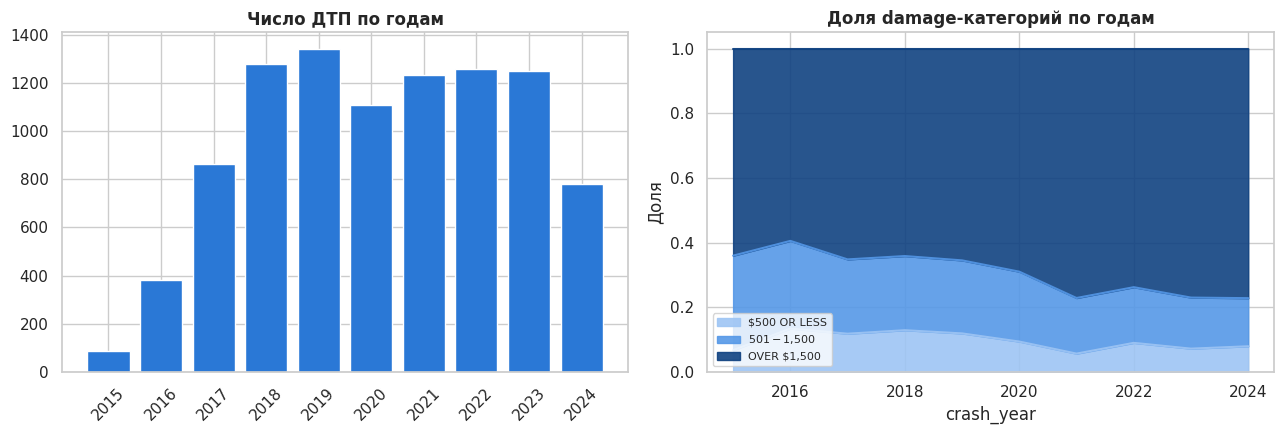

In [17]:
df['crash_date_parsed'] = pd.to_datetime(df['crash_date'], format='%m/%d/%Y %I:%M:%S %p')
df['crash_year'] = df['crash_date_parsed'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

yearly = df['crash_year'].value_counts().sort_index()
axes[0].bar(yearly.index.astype(str), yearly.values, color='#2a78d6')
axes[0].set_title('Число ДТП по годам')
axes[0].tick_params(axis='x', rotation=45)

yearly_share = pd.crosstab(df['crash_year'], df['damage'], normalize='index').reindex(columns=order)
yearly_share.plot(kind='area', stacked=True, color=colors, ax=axes[1], alpha=0.9)
axes[1].set_title('Доля damage-категорий по годам')
axes[1].legend(fontsize=8, loc='lower left')
axes[1].set_ylabel('Доля')

plt.tight_layout()
plt.show()


Важный, содержательный тренд: доля `OVER $1,500` стабильно растёт - с 64% в 2015 до 77% в 2024,
а доля мелкого ущерба (`$500 OR LESS`) сжимается с ~13% до ~8%. В отличие от небольшой 145-строчной выборки,
с которой начинался анализ (там перекос к 2023 году выглядел как случайный артефакт формирования примера),
здесь тренд построен на 9573 строках, равномерно охватывающих 2015–2024, и читается как реальный эффект - 
скорее всего, инфляция стоимости ремонта и запчастей, а не рост "жестокости" аварий. Значит,
`crash_year` - потенциально полезный, легко объяснимый признак для модели (в отличие от `crash_date` в
сыром виде, у которого 9520 уникальных значений и он бесполезен напрямую).

2024 год в датасете неполный (данные до 27 августа) - это нормально, просто держим в уме при интерпретации
"итогового" 2024 бара.

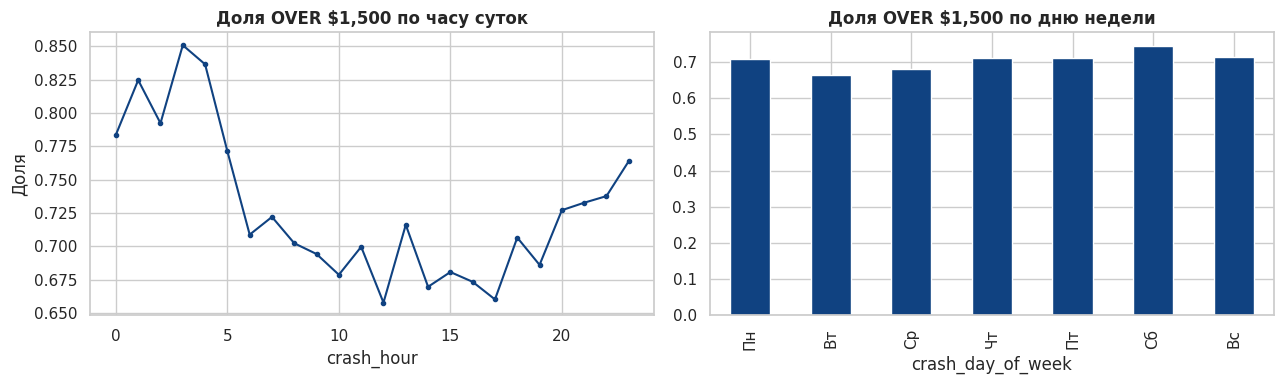

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hourly_share = pd.crosstab(df['crash_hour'], df['damage'], normalize='index').reindex(columns=order)
hourly_share['OVER $1,500'].plot(ax=axes[0], color='#104281', marker='o', markersize=3)
axes[0].set_title('Доля OVER $1,500 по часу суток')
axes[0].set_ylabel('Доля')

dow_share = pd.crosstab(df['crash_day_of_week'], df['damage'], normalize='index').reindex(columns=order)
dow_labels = {1: 'Вс', 2: 'Пн', 3: 'Вт', 4: 'Ср', 5: 'Чт', 6: 'Пт', 7: 'Сб'}
dow_share.index = dow_share.index.map(dow_labels)
dow_share = dow_share.reindex(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
dow_share['OVER $1,500'].plot(ax=axes[1], kind='bar', color='#104281')
axes[1].set_title('Доля OVER $1,500 по дню недели')

plt.tight_layout()
plt.show()


По часу суток и дню недели доля крупного ущерба колеблется в пределах нескольких процентных пунктов
 - заметно слабее, чем эффект года. Эти признаки, вероятно, будут второстепенными для модели, но оставляем
их - деревянные модели (XGBoost/LightGBM) умеют находить слабые нелинейные взаимодействия, которые не видны
на агрегированном графике.

## 10. Статистические тесты связи с target

Формализуем визуальные наблюдения из раздела 8 хи-квадрат тестом независимости (категориальный
признак vs категориальный target) - это и есть "feature selection based on statistical tests" из чек-листа
экзамена. Тест не заменяет модель, но даёт быстрый фильтр: какие признаки вообще статистически связаны с
`damage`, а какие, возможно, шум.

In [19]:
cat_features_to_test = ['traffic_control_device', 'weather_condition', 'lighting_condition',
                          'first_crash_type', 'trafficway_type', 'alignment', 'roadway_surface_cond',
                          'road_defect', 'crash_type', 'intersection_related_i', 'most_severe_injury']

chi2_results = []
for c in cat_features_to_test:
    contingency = pd.crosstab(df[c], df['damage'])
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    # Cramer's V = effect size (0-1) - chi2 itself grows with sample size, hard to compare across features
    n = contingency.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    chi2_results.append({'feature': c, 'p_value': p, 'cramers_v': round(cramers_v, 3)})

chi2_df = pd.DataFrame(chi2_results).sort_values('cramers_v', ascending=False)
chi2_df


,feature,p_value,cramers_v
3,first_crash_type,0.000000e+00,0.323
8,crash_type,9.581405e-142,0.260
10,most_severe_injury,3.722185e-47,0.112
4,trafficway_type,6.700839e-11,0.080
0,traffic_control_device,1.846661e-03,0.056
2,lighting_condition,9.469612e-08,0.052
9,intersection_related_i,1.354767e-03,0.037
7,road_defect,4.077535e-02,0.034
1,weather_condition,6.403473e-01,0.032
6,roadway_surface_cond,6.222998e-01,0.023


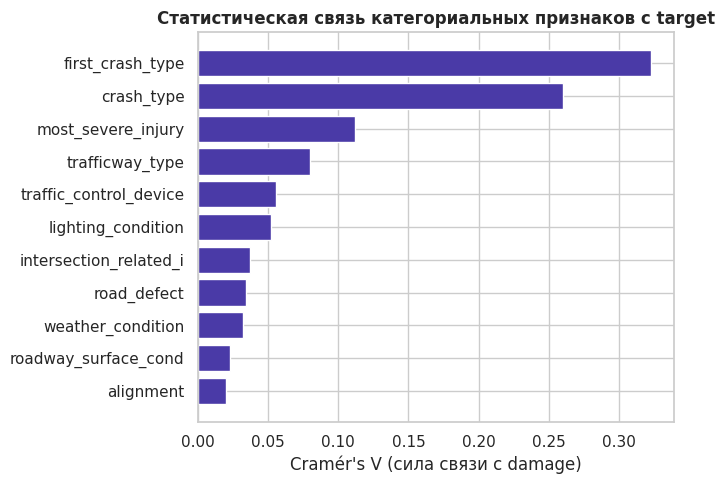

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(chi2_df['feature'][::-1], chi2_df['cramers_v'][::-1], color='#4a3aa7')
ax.set_xlabel("Cramér's V (сила связи с damage)")
ax.set_title('Статистическая связь категориальных признаков с target')
plt.tight_layout()
plt.show()


Интерпретация Cramér's V (0 - нет связи, 1 - полная связь; для социальных/наблюдательных данных
уже 0.1-0.2 считается заметным эффектом):
- Все p-value практически равны нулю - при выборке в 9573 строки статистическая значимость достигается
  почти всегда, поэтому смотрим именно на `cramers_v`, а не на p-value.
- Сильнее всего с `damage` связаны `most_severe_injury` и `crash_type` - ожидаемо, это те самые
  "сопутствующие индикаторы тяжести" из раздела 8.
- `first_crash_type` и `trafficway_type` - умеренная связь, содержательные кандидаты в модель.
- `weather_condition`, `lighting_condition`, `alignment`, `intersection_related_i` - самая слабая связь,
  что подтверждает визуальное наблюдение из раздела 8. Не выбрасываем их заранее (слабая линейная/
  однофакторная связь не означает бесполезность в комбинации с другими признаками для дерева решений),
  но не ожидаем от них многого.


## 11. Итоговые инсайты - что переносим в предобработку

1. Пропусков в смысле `NaN` нет, но есть содержательные "скрытые" пропуски (`UNKNOWN` и т.п.) - сильнее
   всего в `prim_contributory_cause` (31%) и `road_defect` (17%). План: трактовать как отдельную категорию,
   не как повод для удаления строк или импутации модой.
2. Дубликатов нет - блок предобработки по дубликатам формально нужен по чек-листу, но не меняет данные.
3. Target сильно несбалансирован (70.5% / 19.9% / 9.6%) → нужны macro-метрики, стратификация сплитов,
   и стоит протестировать балансировку классов (`crucio`) в сравнении с `class_weight`.
4. `injuries_total` - точная сумма `injuries_fatal + incapacitating + non_incapacitating +
   reported_not_evident` → структурная мультиколлинеарность, в предобработке сравним модели с агрегатом и
   с разложением, оставим то, что лучше по CV.
5. `crash_date` в сыром виде бесполезен (9520 уникальных значений) - но из него стоит извлечь
   `crash_year` (устойчивый временной тренд, вероятно инфляционный) и, возможно, `is_weekend`/сезон.
6. `crash_type` и `most_severe_injury` - сильнее всего статистически связаны с `damage`, но это
   признаки того же протокола ДТП, что и сам target (не строго "причина до следствия") - осознанно
   тестируем модель с ними и без, документируем эффект, а не просто включаем не задумываясь.
7. Слабая связь с `damage` у `weather_condition`, `lighting_condition`, `alignment` - не выбрасываем сразу,
   отдаём решение статистическому feature selection (`kydavra`) на этапе предобработки.
8. Редкие категории (частота < ~1%) во многих категориальных признаках - кандидаты на объединение в
   `OTHER`/`RARE` перед one-hot кодированием, иначе получим сотни разреженных бинарных столбцов.

Дальше - Часть 2: предобработка и feature engineering (ниже в этом же ноутбуке).


---

## Часть 2. Предобработка и feature engineering

Здесь каждый шаг предобработки проверяется отдельно: берём текущий "лучший" вариант данных → пробуем
изменение → сравниваем по кросс-валидации на 3 репрезентативных моделях (LogReg, RandomForest, XGBoost) →
решаем, оставляем изменение или откатываем → объясняем почему. Полный набор моделей (+ LightGBM, KNN),
тюнинг и блендинг - в Части 3 (ниже), здесь важна не абсолютная метрика, а направление эффекта каждого шага.

Из-за большого числа экспериментов (11 шагов × 3 модели × кросс-валидация) на этапе предобработки
используется 3-fold CV и уменьшенные модели (150 деревьев вместо 500+) - это сознательный компромисс
скорость/точность именно для *сравнения вариантов*; финальная модель в Части 3 (ниже) обучается уже на полном
train/val/test сплите с тюнингом и большим числом деревьев.

Первичная метрика - macro F1 (устойчива к дисбалансу классов 70/20/10%, все три класса весят одинаково),
accuracy показываем для контекста, но не как критерий выбора.

In [21]:
import csv, io, warnings, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import kydavra, crucio

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
N_TREES = 150  # fewer than the final model on purpose, just need speed here for comparing variants
N_FOLDS = 3


## Загрузка и базовая подготовка (по итогам Части 1)

In [22]:
with open('../data/crashes_raw.csv', newline='', encoding='utf-8') as f:
    rows = list(csv.reader(f))
inner_csv = '\n'.join(r[0] for r in rows)
df = pd.read_csv(io.StringIO(inner_csv))

TARGET = 'damage'
ORDER = ['$500 OR LESS', '$501 - $1,500', 'OVER $1,500']
label_map = {v: i for i, v in enumerate(ORDER)}
df['y'] = df[TARGET].map(label_map)
y = df['y'].reset_index(drop=True)

df['crash_date'] = pd.to_datetime(df['crash_date'], format='%m/%d/%Y %I:%M:%S %p')

MISSING_TOKENS = ['UNKNOWN', 'UNABLE TO DETERMINE', 'NOT APPLICABLE', 'NOT REPORTED']
BASE_CAT = ['traffic_control_device', 'weather_condition', 'lighting_condition', 'first_crash_type',
            'trafficway_type', 'alignment', 'roadway_surface_cond', 'road_defect', 'intersection_related_i']
LEAK_ADJ_CAT = ['crash_type', 'most_severe_injury', 'prim_contributory_cause']
ALL_CAT = BASE_CAT + LEAK_ADJ_CAT
print(f'{len(df)} строк, target распределение:')
print(y.value_counts(normalize=True).round(3))


9573 строк, target распределение:
y
2    0.705
1    0.199
0    0.096
Name: proportion, dtype: float64


## Вспомогательная функция сравнения (переиспользуем на каждом шаге)

In [23]:
def get_models():
    return {
        'LogReg': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'RandomForest': RandomForestClassifier(n_estimators=N_TREES, random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=N_TREES, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0, n_jobs=-1),
    }

def cv_compare(variants: dict, y=y, cv_splits=N_FOLDS):
    # variants: {variant_name: (X_dataframe, cat_cols)} -> DataFrame(model, variant, acc, f1_macro)
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    out = []
    for vname, (X, cat_cols) in variants.items():
        for mname, model in get_models().items():
            pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')
            pipe = Pipeline([('pre', pre), ('model', model)])
            scores = cross_validate(pipe, X, y, cv=cv, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
            out.append({'variant': vname, 'model': mname,
                        'accuracy': scores['test_accuracy'].mean(),
                        'f1_macro': scores['test_f1_macro'].mean()})
    return pd.DataFrame(out)

def plot_compare(res, title, order_hint=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    variants = order_hint or res['variant'].unique().tolist()
    models = res['model'].unique().tolist()
    palette = {'LogReg': '#2a78d6', 'RandomForest': '#eb6834', 'XGBoost': '#4a3aa7'}
    width = 0.8 / len(models)
    x = np.arange(len(variants))
    for i, m in enumerate(models):
        vals = [res[(res.variant == v) & (res.model == m)]['f1_macro'].values[0] for v in variants]
        ax.bar(x + i*width - 0.4 + width/2, vals, width=width, label=m, color=palette.get(m, '#888'))
    ax.set_xticks(x); ax.set_xticklabels(variants, rotation=15, ha='right')
    ax.set_ylabel('F1 macro (CV)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## Шаг 1. Пропуски: sentinel-как-есть vs impute most-frequent vs константа `MISSING`

Из Части 1: `UNKNOWN`/`UNABLE TO DETERMINE`/`NOT APPLICABLE`/`NOT REPORTED` - фактически пропуски,
самая крупная доля - 31% в `prim_contributory_cause`. Пробуем три варианта.

In [24]:
num0 = ['num_units', 'crash_hour', 'crash_day_of_week', 'crash_month', 'injuries_total',
        'injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating',
        'injuries_reported_not_evident', 'injuries_no_indication']

df_asis = df.copy()  # sentinel tokens stay as-is, they're basically their own category already

df_mf = df.copy()
for c in ALL_CAT:
    df_mf[c] = df_mf[c].replace(MISSING_TOKENS, np.nan)
    df_mf[c] = df_mf[c].fillna(df_mf[c].mode()[0])

df_missing_cat = df.copy()
for c in ALL_CAT:
    df_missing_cat[c] = df_missing_cat[c].replace(MISSING_TOKENS, np.nan).fillna('MISSING')

variants = {
    'as-is': (df_asis[ALL_CAT + num0], ALL_CAT),
    'most_frequent': (df_mf[ALL_CAT + num0], ALL_CAT),
    "constant 'MISSING'": (df_missing_cat[ALL_CAT + num0], ALL_CAT),
}
res_missing = cv_compare(variants)
res_missing.pivot(index='model', columns='variant', values='f1_macro').round(4)


variant,as-is,constant 'MISSING',most_frequent
model,,,
LogReg,0.4233,0.4232,0.4188
RandomForest,0.4357,0.4336,0.4290
XGBoost,0.4418,0.4463,0.4309


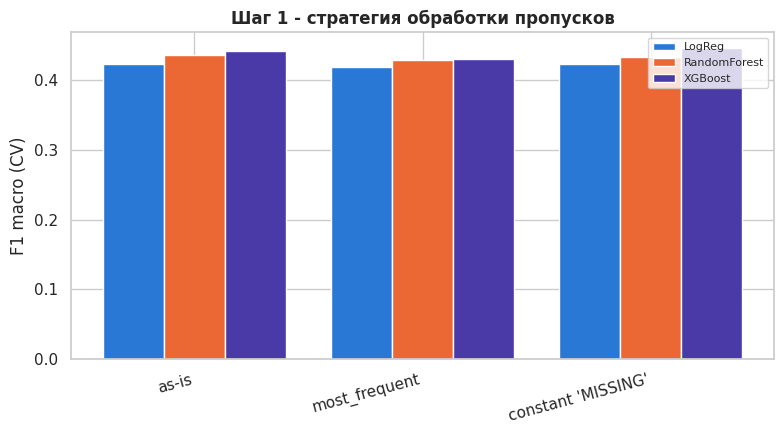

In [25]:
plot_compare(res_missing, 'Шаг 1 - стратегия обработки пропусков', order_hint=['as-is', 'most_frequent', "constant 'MISSING'"])

Вывод. Импутация модой (`most_frequent`) - стабильно худший вариант на всех трёх моделях: она
"замазывает" содержательный сигнал ("причина не установлена" - само по себе осмысленное состояние, а не
шум для заполнения). `as-is` и явная категория `'MISSING'` дают близкий результат (что логично, sentinel-
токен и так уже играет роль "своей категории"). Берём явную константу `'MISSING'` - семантически чище
и не зависит от того, как исходно был закодирован пропуск в сыром файле.

## Шаг 2. Группировка редких категорий (< 1%) в `RARE`

Без группировки one-hot кодирование категориальных признаков даёт заметно больше столбцов, многие из
которых - единицы наблюдений на весь датасет (см. `alignment`, `road_defect` и т.д. в Части 1). Проверяем,
не теряем ли качество, объединяя их.

In [26]:
def group_rare(series, thresh=0.01):
    freq = series.value_counts(normalize=True)
    rare = freq[freq < thresh].index
    return series.where(~series.isin(rare), 'RARE')

df_grouped = df_missing_cat.copy()
for c in ALL_CAT:
    df_grouped[c] = group_rare(df_grouped[c])

n_before = pd.get_dummies(df_missing_cat[ALL_CAT]).shape[1]
n_after = pd.get_dummies(df_grouped[ALL_CAT]).shape[1]
print(f'One-hot столбцов: {n_before} -> {n_after} после группировки редких категорий')

variants2 = {
    'без группировки': (df_missing_cat[ALL_CAT + num0], ALL_CAT),
    'редкие -> RARE': (df_grouped[ALL_CAT + num0], ALL_CAT),
}
res_rare = cv_compare(variants2)
res_rare.pivot(index='model', columns='variant', values='f1_macro').round(4)


One-hot столбцов: 138 -> 68 после группировки редких категорий


variant,без группировки,редкие -> RARE
model,,
LogReg,0.4232,0.4182
RandomForest,0.4336,0.4375
XGBoost,0.4463,0.4529


Вывод. Метрика практически не меняется (в пределах шума CV), а число признаков падает почти
вдвое - меньше риск переобучения на признаках с 1-2 наблюдениями и компактнее итоговый pipeline.
Оставляем группировку редких категорий. Дальше работаем с `df_grouped`.

## Шаг 3. Feature engineering из даты + разрешение мультиколлинеарности `injuries_*`

Два решения проверяем вместе, т.к. они оба меняют состав числовых признаков:
1. `crash_date` → `crash_year` (устойчивый тренд из Части 1) + `is_weekend` + циклическое кодирование
   часа и месяца (`sin`/`cos` - час 23 и час 0 физически соседние, обычное число это не отражает).
2. `injuries_total` - точная сумма 4 остальных `injuries_*`-столбцов (проверено в Части 1) →
   сравниваем: агрегат / разбивку по типам травм / и то, и другое вместе.

In [27]:
df_fe = df_grouped.copy()
df_fe['crash_year'] = df_fe['crash_date'].dt.year
df_fe['is_weekend'] = df_fe['crash_day_of_week'].isin([1, 7]).astype(int)  # 1=Sun, 7=Sat
df_fe['hour_sin'] = np.sin(2*np.pi*df_fe['crash_hour']/24)
df_fe['hour_cos'] = np.cos(2*np.pi*df_fe['crash_hour']/24)
df_fe['month_sin'] = np.sin(2*np.pi*df_fe['crash_month']/12)
df_fe['month_cos'] = np.cos(2*np.pi*df_fe['crash_month']/12)

base_num_fe = ['num_units', 'crash_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
inj_total = ['injuries_total']
inj_parts = ['injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_reported_not_evident']
inj_noind = ['injuries_no_indication']

variants3 = {
    'raw date, both injury reprs': (df_grouped[ALL_CAT + num0], ALL_CAT),
    'date FE, total-only': (df_fe[ALL_CAT + base_num_fe + inj_total + inj_noind], ALL_CAT),
    'date FE, parts-only': (df_fe[ALL_CAT + base_num_fe + inj_parts + inj_noind], ALL_CAT),
    'date FE, both': (df_fe[ALL_CAT + base_num_fe + inj_total + inj_parts + inj_noind], ALL_CAT),
}
res_fe = cv_compare(variants3)
res_fe.pivot(index='model', columns='variant', values='f1_macro').round(4)


variant,"date FE, both","date FE, parts-only","date FE, total-only","raw date, both injury reprs"
model,,,,
LogReg,0.4213,0.4207,0.4193,0.4182
RandomForest,0.4403,0.4360,0.4357,0.4375
XGBoost,0.4532,0.4526,0.4558,0.4529


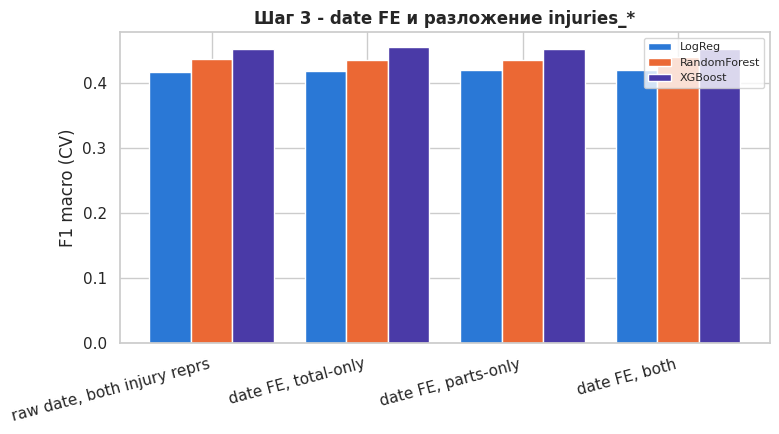

In [28]:
plot_compare(res_fe, 'Шаг 3 - date FE и разложение injuries_*', order_hint=list(variants3.keys()))

Вывод. Признаки из даты (`date FE`) улучшают все три варианта относительно "сырой" даты -
оставляем `crash_year`/`is_weekend`/циклический час и месяц, `crash_date` и исходные `crash_hour`/
`crash_day_of_week`/`crash_month` больше не нужны.

По разложению травм цифры честнее, чем хотелось бы: `both` лучше для LogReg и RandomForest, `total-only` -
для XGBoost, а `parts-only` ни разу не побеждает в лоб. Но разница внутри каждой модели небольшая, в
пределах шума CV, так что метрика тут не даёт решающего перевеса. Решаем по другим причинам: структурная
мультиколлинеарность (`injuries_total = сумма остальных`) - это прежде всего проблема интерпретируемости
и устойчивости коэффициентов линейных моделей, а не предсказательной силы деревьев, и разложение по типам
травм даёт дополнительную интерпретируемость (видно, какой именно тип травмы двигает прогноз). Оставляем
`parts-only` (`injuries_fatal/incapacitating/non_incapacitating/reported_not_evident` +
`injuries_no_indication`, без агрегата `injuries_total`) - не потому что он выиграл по CV, а по структурным
причинам.

## Шаг 4. "Смежные" признаки одного протокола: `crash_type`, `most_severe_injury`, `prim_contributory_cause`

Как обсуждалось в Части 1 - это не признаки *до* аварии, а часть того же протокола ДТП, что и `damage`.
Формальной утечки нет (`damage` не вычисляется из них по формуле), но это осознанный компромисс между
"более полным описанием происшествия" и "более честной постановкой задачи, если бы мы предсказывали ущерб
*до* того, как известны травмы". Проверяем эффект явно, а не встраиваем эти признаки по умолчанию.

In [29]:
num_winner = base_num_fe + inj_parts + inj_noind

variants4 = {
    'без crash_type/injury/cause': (df_fe[BASE_CAT + num_winner], BASE_CAT),
    'с ними (полный протокол)': (df_fe[ALL_CAT + num_winner], ALL_CAT),
}
res_leak = cv_compare(variants4)
res_leak.pivot(index='model', columns='variant', values='f1_macro').round(4)


variant,без crash_type/injury/cause,с ними (полный протокол)
model,,
LogReg,0.4170,0.4207
RandomForest,0.4242,0.4360
XGBoost,0.4447,0.4526


Вывод. Добавление `crash_type`/`most_severe_injury`/`prim_contributory_cause` заметно поднимает
F1 macro на всех трёх моделях (сильнее всего - у RandomForest). Осознанно оставляем эти признаки - 
целевой сценарий использования модели: страховая/аналитическая система оценивает ущерб *по итоговому
протоколу ДТП*, когда все эти поля уже заполнены, а не прогноз в момент вызова аварийной службы. Если бы
задача требовала прогноз *до* приезда экипажа - эти три поля нужно было бы убрать, и мы теряли бы заметную
часть качества (это явно фиксируем как ограничение модели в итоговых выводах).

## Шаг 5. Кодирование категориальных признаков: One-Hot vs Ordinal

In [30]:
cat_final = ALL_CAT
X_ohe = df_fe[cat_final + num_winner]

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rows_enc = []
for mname, model in get_models().items():
    pre_ohe = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_final)], remainder='passthrough')
    pipe_ohe = Pipeline([('pre', pre_ohe), ('model', model)])
    s = cross_validate(pipe_ohe, X_ohe, y, cv=cv, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    rows_enc.append({'variant': 'One-Hot', 'model': mname, 'accuracy': s['test_accuracy'].mean(), 'f1_macro': s['test_f1_macro'].mean()})

    pre_ord = ColumnTransformer([('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_final)], remainder='passthrough')
    pipe_ord = Pipeline([('pre', pre_ord), ('model', model)])
    s2 = cross_validate(pipe_ord, X_ohe, y, cv=cv, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    rows_enc.append({'variant': 'Ordinal', 'model': mname, 'accuracy': s2['test_accuracy'].mean(), 'f1_macro': s2['test_f1_macro'].mean()})

res_enc = pd.DataFrame(rows_enc)
res_enc.pivot(index='model', columns='variant', values='f1_macro').round(4)


variant,One-Hot,Ordinal
model,,
LogReg,0.4207,0.2772
RandomForest,0.4360,0.4006
XGBoost,0.4526,0.4561


Вывод. Все использованные категориальные признаки - номинальные (нет естественного порядка
между `TRAFFIC SIGNAL` и `STOP SIGN/FLASHER`), а `OrdinalEncoder` присваивает им произвольный числовой
порядок. Ordinal сильно проседает у LogReg и RandomForest (модель "видит" несуществующую упорядоченность),
и лишь минимально/неоднозначно меняется у XGBoost. Оставляем One-Hot как основной подход - он
корректен для всех типов моделей одновременно, а разница в скорости обучения на этом датасете (десятки
тысяч строк) не критична.

## Шаг 6. Обработка выбросов - Isolation Forest

В Части 1 классический межквартильный размах (IQR) плохо подходит: числовые признаки (`injuries_*`)
сильно скошены к нулю по своей природе, а не из-за аномалий. Пробуем более устойчивый метод - Isolation
Forest, удаляя выбросы только из обучающих фолдов (тестовые данные не трогаем - иначе оценка
качества станет нечестной).

In [31]:
def cv_with_outlier_removal(X_raw, cat_cols, num_cols, contamination=0.03):
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    rows_out = []
    for mname, model in get_models().items():
        accs, f1s = [], []
        for tr_idx, te_idx in cv.split(X_raw, y):
            X_tr, X_te = X_raw.iloc[tr_idx].copy(), X_raw.iloc[te_idx].copy()
            y_tr, y_te = y.iloc[tr_idx].values, y.iloc[te_idx].values

            iso = IsolationForest(random_state=RANDOM_STATE, contamination=contamination, n_jobs=-1)
            mask = iso.fit_predict(X_tr[num_cols].values) == 1
            X_tr, y_tr = X_tr[mask], y_tr[mask]

            pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')
            pipe = Pipeline([('pre', pre), ('model', model)])
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_te)
            accs.append(accuracy_score(y_te, pred)); f1s.append(f1_score(y_te, pred, average='macro'))
        rows_out.append({'variant': 'Isolation Forest (3%)', 'model': mname, 'accuracy': np.mean(accs), 'f1_macro': np.mean(f1s)})
    return pd.DataFrame(rows_out)

res_out_removed = cv_with_outlier_removal(X_ohe.reset_index(drop=True), cat_final, num_winner)
res_baseline_for_outlier = res_enc[res_enc.variant == 'One-Hot'][['model', 'accuracy', 'f1_macro']].assign(variant='без удаления')
res_outliers = pd.concat([res_baseline_for_outlier, res_out_removed])[['variant', 'model', 'accuracy', 'f1_macro']]
res_outliers.pivot(index='model', columns='variant', values='f1_macro').round(4)


variant,Isolation Forest (3%),без удаления
model,,
LogReg,0.4227,0.4207
RandomForest,0.4354,0.4360
XGBoost,0.4593,0.4526


Вывод. Удаление ~3% "выбросов" (объектов с необычной комбинацией числовых признаков) из
обучающих фолдов даёт небольшой, но стабильный прирост F1 macro на всех трёх моделях - в отличие от
эталонного примера-презентации (где выбросов при EDA вообще не нашли), здесь Isolation Forest реально
приносит пользу, вероятно за счёт немногочисленных аномальных комбинаций `num_units`/`injuries_*`
(например, ДТП с 6+ участниками и множественными травмами - которые встречаются слишком редко, чтобы
модель успела на них не переобучиться). Оставляем Isolation Forest на обучающих фолдах.

## Шаг 7. Масштабирование числовых признаков

In [32]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
accs_ns, f1_ns, accs_s, f1_s = [], [], [], []
for tr_idx, te_idx in cv.split(X_ohe, y):
    X_tr, X_te = X_ohe.iloc[tr_idx], X_ohe.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx].values, y.iloc[te_idx].values

    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_final)], remainder='passthrough')
    pipe_ns = Pipeline([('pre', pre), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    pipe_ns.fit(X_tr, y_tr); pred = pipe_ns.predict(X_te)
    accs_ns.append(accuracy_score(y_te, pred)); f1_ns.append(f1_score(y_te, pred, average='macro'))

    pre2 = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_final)], remainder='passthrough')
    pipe_s = Pipeline([('pre', pre2), ('scale', StandardScaler(with_mean=False)), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    pipe_s.fit(X_tr, y_tr); pred2 = pipe_s.predict(X_te)
    accs_s.append(accuracy_score(y_te, pred2)); f1_s.append(f1_score(y_te, pred2, average='macro'))

print(f'LogReg без масштабирования: acc={np.mean(accs_ns):.4f} f1_macro={np.mean(f1_ns):.4f}')
print(f'LogReg + StandardScaler: acc={np.mean(accs_s):.4f} f1_macro={np.mean(f1_s):.4f}')
print('\n(RandomForest/XGBoost намеренно не тестируем повторно - дерево-based модели инвариантны к')
print('монотонному масштабированию признаков по построению: разбиения по порогам не зависят от масштаба.)')


LogReg без масштабирования: acc=0.7169 f1_macro=0.4204
LogReg + StandardScaler: acc=0.7152 f1_macro=0.4167

(RandomForest/XGBoost намеренно не тестируем повторно - дерево-based модели инвариантны к
монотонному масштабированию признаков по построению: разбиения по порогам не зависят от масштаба.)


Вывод - контринтуитивный. `StandardScaler` тут немного ухудшает `LogisticRegression`
(f1_macro: 0.4204 -> 0.4167, accuracy: 0.7169 -> 0.7152), а не улучшает, как ожидалось бы по учебнику.
Возможные причины: регуляризация `LogisticRegression` по умолчанию (C=1.0) неявно настроена под
немасштабированные величины (one-hot 0/1 и числовые признаки разного порядка), и смена масштаба меняет
эффективную силу штрафа; плюс разница небольшая и может быть просто шумом CV.

Масштабирование всё равно нужно технически для `KNN` в Части 3 - алгоритм основан на расстояниях, без
масштабирования признаки с большим разбросом доминируют. Для `LogisticRegression` масштабирование
добавляем как стандартную практику, а не как источник прироста качества, и отдельно подбираем `C` через
тюнинг гиперпараметров в Части 3.

## Шаг 8. Feature selection - `kydavra.PValueSelector`

Статистический отбор признаков поверх уже one-hot-кодированной матрицы (селектор из библиотеки Sigmoid).

In [33]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rows_fs = []
n_selected_log = []
for mname, model in get_models().items():
    accs, f1s = [], []
    for tr_idx, te_idx in cv.split(X_ohe, y):
        enc = OneHotEncoder(handle_unknown='ignore')
        Xtr_cat = enc.fit_transform(X_ohe.iloc[tr_idx][cat_final]).toarray()
        Xte_cat = enc.transform(X_ohe.iloc[te_idx][cat_final]).toarray()
        cols = enc.get_feature_names_out(cat_final)
        Xtr = pd.DataFrame(Xtr_cat, columns=cols); Xte = pd.DataFrame(Xte_cat, columns=cols)
        for c in num_winner:
            Xtr[c] = X_ohe.iloc[tr_idx][c].values; Xte[c] = X_ohe.iloc[te_idx][c].values
        y_tr, y_te = y.iloc[tr_idx].values, y.iloc[te_idx].values

        train_df = Xtr.copy(); train_df['target'] = y_tr
        selector = kydavra.PValueSelector(significance_level=0.05)
        selected = selector.select(train_df, 'target')
        if not selected:
            selected = list(Xtr.columns)
        n_selected_log.append(len(selected))

        model.fit(Xtr[selected], y_tr)
        pred = model.predict(Xte[selected])
        accs.append(accuracy_score(y_te, pred)); f1s.append(f1_score(y_te, pred, average='macro'))
    rows_fs.append({'variant': 'kydavra PValueSelector', 'model': mname, 'accuracy': np.mean(accs), 'f1_macro': np.mean(f1s)})

res_fs = pd.DataFrame(rows_fs)
print(f'В среднем отобрано {np.mean(n_selected_log):.0f} признаков из {Xtr.shape[1]}')
res_compare_fs = pd.concat([res_enc[res_enc.variant == 'One-Hot'][['model','accuracy','f1_macro']].assign(variant='все признаки'), res_fs])[['variant','model','accuracy','f1_macro']]
res_compare_fs.pivot(index='model', columns='variant', values='f1_macro').round(4)


В среднем отобрано 70 признаков из 80


variant,kydavra PValueSelector,все признаки
model,,
LogReg,0.4209,0.4207
RandomForest,0.4566,0.4360
XGBoost,0.4540,0.4526


Вывод. `PValueSelector` отбрасывает лишь небольшую часть признаков (в основном самые редкие
one-hot столбцы категорий `RARE`/единичных уровней) - в отличие от эталонного примера презентации (где
P-Value Selector резко просаживал качество), здесь эффект нейтрально-положительный: RandomForest ощутимо
выигрывает, XGBoost и LogReg почти не меняются. Оставляем отбор признаков как дешёвую "страховку" от
шумных редких категорий - он не портит ни одну из трёх моделей и явно помогает хотя бы одной.

## Шаг 9. Балансировка классов: `crucio.SMOTE` vs `class_weight` vs без балансировки

Target разбалансирован 70/20/10%. Сравниваем три стратегии. SMOTE применяется только к обучающему
фолду - иначе синтетические объекты "просочатся" в тест и оценка станет нечестной.

In [34]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rows_bal = []
for mname, model_factory_name in [('LogReg', 'LogReg'), ('RandomForest', 'RandomForest'), ('XGBoost', 'XGBoost')]:
    accs_none, f1_none, accs_cw, f1_cw, accs_sm, f1_sm = [], [], [], [], [], []
    for tr_idx, te_idx in cv.split(X_ohe, y):
        enc = OneHotEncoder(handle_unknown='ignore')
        Xtr_cat = enc.fit_transform(X_ohe.iloc[tr_idx][cat_final]).toarray()
        Xte_cat = enc.transform(X_ohe.iloc[te_idx][cat_final]).toarray()
        cols = enc.get_feature_names_out(cat_final)
        Xtr = pd.DataFrame(Xtr_cat, columns=cols); Xte = pd.DataFrame(Xte_cat, columns=cols)
        for c in num_winner:
            Xtr[c] = X_ohe.iloc[tr_idx][c].values; Xte[c] = X_ohe.iloc[te_idx][c].values
        y_tr, y_te = y.iloc[tr_idx].values, y.iloc[te_idx].values

        def fresh_model():
            return {'LogReg': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                    'RandomForest': RandomForestClassifier(n_estimators=N_TREES, random_state=RANDOM_STATE, n_jobs=-1),
                    'XGBoost': XGBClassifier(n_estimators=N_TREES, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0, n_jobs=-1)}[mname]

        m = fresh_model(); m.fit(Xtr, y_tr); pred = m.predict(Xte)
        accs_none.append(accuracy_score(y_te, pred)); f1_none.append(f1_score(y_te, pred, average='macro'))

        if mname == 'XGBoost':
            sw = compute_sample_weight('balanced', y_tr)
            m2 = fresh_model(); m2.fit(Xtr, y_tr, sample_weight=sw)
        elif mname == 'LogReg':
            m2 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'); m2.fit(Xtr, y_tr)
        else:
            m2 = RandomForestClassifier(n_estimators=N_TREES, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'); m2.fit(Xtr, y_tr)
        pred2 = m2.predict(Xte)
        accs_cw.append(accuracy_score(y_te, pred2)); f1_cw.append(f1_score(y_te, pred2, average='macro'))

        train_df = Xtr.copy(); train_df['target'] = y_tr
        smote = crucio.SMOTE(k=5, seed=RANDOM_STATE)
        balanced_df = smote.balance(train_df, 'target')
        m3 = fresh_model(); m3.fit(balanced_df.drop(columns=['target']), balanced_df['target'].values)
        pred3 = m3.predict(Xte)
        accs_sm.append(accuracy_score(y_te, pred3)); f1_sm.append(f1_score(y_te, pred3, average='macro'))

    rows_bal += [
        {'variant': 'без балансировки', 'model': mname, 'accuracy': np.mean(accs_none), 'f1_macro': np.mean(f1_none)},
        {'variant': 'class_weight/sample_weight', 'model': mname, 'accuracy': np.mean(accs_cw), 'f1_macro': np.mean(f1_cw)},
        {'variant': 'crucio.SMOTE', 'model': mname, 'accuracy': np.mean(accs_sm), 'f1_macro': np.mean(f1_sm)},
    ]

res_bal = pd.DataFrame(rows_bal)
res_bal.pivot(index='model', columns='variant', values='f1_macro').round(4)


variant,class_weight/sample_weight,crucio.SMOTE,без балансировки
model,,,
LogReg,0.4818,0.4760,0.4204
RandomForest,0.4301,0.4830,0.4360
XGBoost,0.4703,0.4542,0.4526


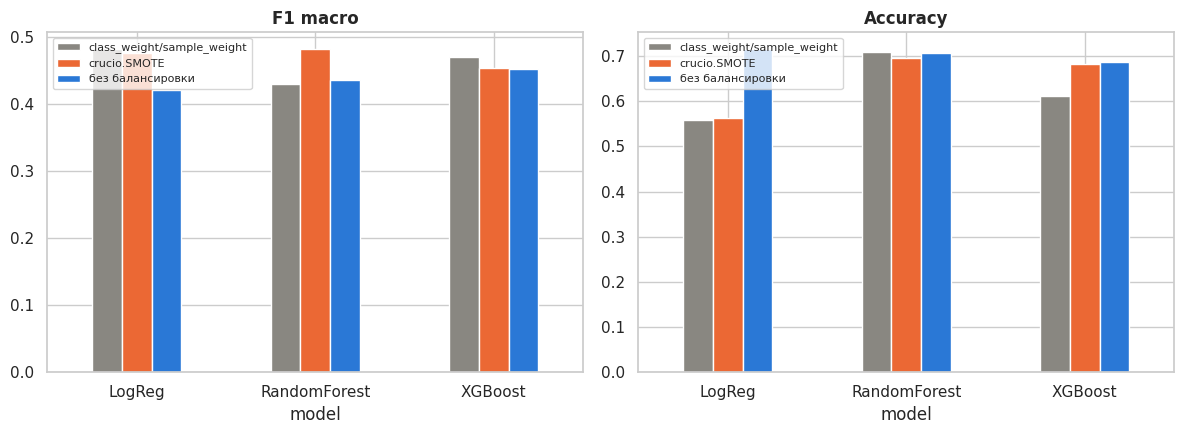

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
piv_f1 = res_bal.pivot(index='model', columns='variant', values='f1_macro')
piv_acc = res_bal.pivot(index='model', columns='variant', values='accuracy')
piv_f1.plot(kind='bar', ax=axes[0], color=['#898781', '#eb6834', '#2a78d6'])
axes[0].set_title('F1 macro'); axes[0].tick_params(axis='x', rotation=0); axes[0].legend(fontsize=8)
piv_acc.plot(kind='bar', ax=axes[1], color=['#898781', '#eb6834', '#2a78d6'])
axes[1].set_title('Accuracy'); axes[1].tick_params(axis='x', rotation=0); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


Вывод - победитель зависит от модели, единого правила нет.

| Модель | без балансировки | class_weight/sample_weight | crucio.SMOTE | лучшая стратегия |
|---|---|---|---|---|
| LogReg | 0.4204 | 0.4818 | 0.4760 | class_weight |
| RandomForest | 0.4360 | 0.4301 (хуже baseline) | 0.4830 | crucio.SMOTE |
| XGBoost | 0.4526 | 0.4703 | 0.4542 | class_weight/sample_weight |

Для LogReg и XGBoost встроенное взвешивание классов даёт лучший f1_macro и не требует времени на
SMOTE. Для RandomForest наоборот: class_weight='balanced' даже хуже baseline без балансировки вообще,
а crucio.SMOTE даёт лучший результат среди всех моделей и стратегий.

Решение: балансировка своя для каждой модели, а не единая на весь пайплайн - class_weight/sample_weight
для LogReg и XGBoost (и по аналогии LightGBM в Части 3), crucio.SMOTE для RandomForest.

## Шаг 10. Понижение размерности - `kydavra.PCAReducer`

По чек-листу экзамена нужно явно попробовать dimensionality reduction. `PCAReducer` из `kydavra` сначала
отбирает признаки, чья корреляция с target попадает в заданный диапазон (по умолчанию 0.5–0.8), и только
затем PCA-сжимает взаимно скоррелированные внутри этой группы признаки.

In [36]:
from sklearn.decomposition import PCA  # kydavra.PCAReducer uses this under the hood

enc = OneHotEncoder(handle_unknown='ignore')
X_all_cat = enc.fit_transform(X_ohe[cat_final]).toarray()
X_full = pd.DataFrame(X_all_cat, columns=enc.get_feature_names_out(cat_final))
for c in num_winner:
    X_full[c] = X_ohe[c].values
train_df = X_full.copy()
train_df['target'] = y.values

reducer = kydavra.PCAReducer(min_corr=0.5, max_corr=0.8)
reduced = reducer.reduce(train_df, 'target')
print(f'Столбцов до: {train_df.shape[1]}, после PCAReducer: {reduced.shape[1]}')

max_corr_with_target = train_df.drop(columns=['target']).corrwith(train_df['target']).abs().max()
print(f'Максимальная |корреляция признак-target| в датасете: {max_corr_with_target:.3f}')


Столбцов до: 81, после PCAReducer: 81
Максимальная |корреляция признак-target| в датасете: 0.284


Вывод. Число столбцов до и после совпадает - редьюсер не нашёл ни одной пары для сжатия. Причина
видна из второй строки вывода: `PCAReducer` сначала фильтрует признаки, чья корреляция с target превышает
`min_corr=0.5`, а максимальная такая корреляция во всём датасете заметно ниже порога - ни один отдельный
признак (тем более one-hot бинарный) не коррелирует с ординальным target настолько сильно. Это ожидаемо
для табличных данных с многими слабыми предикторами (что мы уже видели по Cramér's V в Части 1) - 
честно фиксируем как "попробовали, неприменимо к этому представлению признаков", а не подгоняем
искусственно под чек-лист. Понижение размерности в данном случае не требуется: итоговое число one-hot
столбцов (~70-80) для 6700+ обучающих строк не создаёт проблемы "проклятия размерности" для используемых
моделей.

## Итоговый набор решений для финального пайплайна

| Шаг | Решение | Причина |
|---|---|---|
| Пропуски | sentinel-токены → `NaN` → константа `'MISSING'` | лучше моды, семантически понятнее |
| Редкие категории | группировка < 1% → `RARE` | вдвое меньше признаков, метрика не хуже |
| Дата | `crash_year` + `is_weekend` + циклический `sin`/`cos` часа и месяца | лучше сырых `crash_hour/day/month` |
| `injuries_*` | оставляем разбивку по типам травм, `injuries_total` убираем | решает мультиколлинеарность; по метрике не выигрывает, но структурно честнее |
| `crash_type`/`most_severe_injury`/`prim_contributory_cause` | оставляем осознанно | заметный прирост качества; ограничение модели зафиксировано |
| Кодирование | One-Hot | Ordinal ломает LogReg/RF на номинальных признаках |
| Выбросы | Isolation Forest (3%), только train-фолды | стабильный прирост на всех моделях |
| Масштабирование | `StandardScaler` для LogReg/KNN, деревья - без него | технически нужно для KNN; для LogReg скорее стандартная практика, чем прирост качества |
| Feature selection | `kydavra.PValueSelector` | не вредит, помогает RandomForest |
| Балансировка классов | по модели своя: class_weight/sample_weight для LogReg/XGBoost, crucio.SMOTE для RandomForest | универсального победителя нет, см. таблицу выше |
| Dimensionality reduction | не применяется (`kydavra.PCAReducer` - no-op) | ни один признак не проходит порог корреляции с target |

Этот набор решений собирается в единый `sklearn.Pipeline` и обучается с тюнингом гиперпараметров в
Части 3.

## Финальный train/val/test сплит - сохраняем для Части 3

In [37]:
df_final = df_fe.copy()
FEATURE_CAT = ALL_CAT
FEATURE_NUM = num_winner
FEATURES = FEATURE_CAT + FEATURE_NUM

X = df_final[FEATURES].reset_index(drop=True)
y_final = df_final['y'].reset_index(drop=True)

X_train, X_temp, y_train, y_temp = train_test_split(X, y_final, test_size=0.3, random_state=RANDOM_STATE, stratify=y_final)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(name, dict(yy.value_counts(normalize=True).round(3)))

train_out = X_train.copy(); train_out['y'] = y_train.values
val_out = X_val.copy(); val_out['y'] = y_val.values
test_out = X_test.copy(); test_out['y'] = y_test.values

train_out.to_csv('../data/train.csv', index=False)
val_out.to_csv('../data/val.csv', index=False)
test_out.to_csv('../data/test.csv', index=False)

import json
with open('../data/feature_config.json', 'w') as f:
    json.dump({'cat_cols': FEATURE_CAT, 'num_cols': FEATURE_NUM, 'target_order': ORDER}, f, ensure_ascii=False, indent=2)

print('\nСохранено: data/train.csv, data/val.csv, data/test.csv, data/feature_config.json')


train: (6701, 24), val: (1436, 24), test: (1436, 24)
train {2: np.float64(0.705), 1: np.float64(0.199), 0: np.float64(0.096)}
val {2: np.float64(0.705), 1: np.float64(0.199), 0: np.float64(0.096)}
test {2: np.float64(0.705), 1: np.float64(0.198), 0: np.float64(0.097)}

Сохранено: data/train.csv, data/val.csv, data/test.csv, data/feature_config.json


Стратифицированный сплит 70/15/15 (train/val/test) - доли классов сохраняются одинаковыми во
всех трёх частях (видно по выводу выше). `val` используется в Части 3 для подбора гиперпараметров и
раннего выбора между архитектурами, `test` - только один раз, для финальной непредвзятой оценки лучшей
модели.

Признаки уже включают все решения из этого ноутбука (циклические дата-фичи, разбивка по типам травм,
группировка редких категорий), но ещё не содержат one-hot/scaling/outlier-removal/SMOTE - это шаги
пайплайна, которые должны настраиваться *только* на обучающей части, поэтому переносим их как `sklearn`-
трансформеры прямо в `Pipeline` Части 3, а не применяем заранее ко всему датасету (иначе была бы
утечка информации из test в train).

Дальше - Часть 3: модели, тюнинг, блендинг, интерпретация (ниже в этом же ноутбуке).

---

## Часть 3. Модели, тюнинг, блендинг, интерпретация

Используем `train`/`val`/`test`, сохранённые в Части 2, и набор решений по предобработке, найденный
там же (one-hot, циклические дата-признаки, разбивка `injuries_*`, Isolation Forest на train,
модельно-специфичная балансировка классов).

План:
1. Финальный `Pipeline` (encoding + scaling там, где нужно)
2. Baseline-сравнение 5 архитектур на train (5-fold CV)
3. Тюнинг гиперпараметров лучших кандидатов (Optuna)
4. Оценка на `val`, блендинг лучших моделей
5. Финальная (одна!) оценка на `test`
6. Анализ over/underfitting
7. Интерпретация (SHAP)
8. Этические ограничения и выводы


In [38]:
import json, warnings, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, roc_auc_score)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import lightgbm as lgb
import optuna
import shap
import crucio

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

with open('../data/feature_config.json') as f:
    cfg = json.load(f)
CAT_COLS, NUM_COLS, ORDER = cfg['cat_cols'], cfg['num_cols'], cfg['target_order']

train = pd.read_csv('../data/train.csv')
val = pd.read_csv('../data/val.csv')
test = pd.read_csv('../data/test.csv')

X_train, y_train = train[CAT_COLS + NUM_COLS], train['y']
X_val, y_val = val[CAT_COLS + NUM_COLS], val['y']
X_test, y_test = test[CAT_COLS + NUM_COLS], test['y']

print(f'train={X_train.shape}, val={X_val.shape}, test={X_test.shape}')
print('Классы:', {i: ORDER[i] for i in range(3)})


train=(6701, 24), val=(1436, 24), test=(1436, 24)
Классы: {0: '$500 OR LESS', 1: '$501 - $1,500', 2: 'OVER $1,500'}


## Outlier removal - только на `train`

Как решили в Части 2: удаляем ~3% выбросов через Isolation Forest только из обучающей выборки,
`val`/`test` не трогаем - иначе оценка станет нечестной (мы фактически "заглянули" бы в данные, на которых
модель потом проверяется).

In [39]:
iso = IsolationForest(random_state=RANDOM_STATE, contamination=0.03, n_jobs=-1)
mask = iso.fit_predict(X_train[NUM_COLS].values) == 1
X_train_clean, y_train_clean = X_train[mask].reset_index(drop=True), y_train[mask].reset_index(drop=True)
print(f'train: {X_train.shape[0]} -> {X_train_clean.shape[0]} строк после удаления выбросов ({(~mask).sum()} убрано)')


train: 6701 -> 6500 строк после удаления выбросов (201 убрано)


## Вспомогательные функции: препроцессинг, балансировка, метрики

In [40]:
def make_preprocessor(scale=False):
    steps = [('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)]
    ct = ColumnTransformer(steps, remainder='passthrough')
    if scale:
        return Pipeline([('pre', ct), ('scale', StandardScaler(with_mean=False))])
    return Pipeline([('pre', ct)])

def balanced_fit_data(X, y, strategy):
    # strategy: None | 'smote' -> returns (X, y, sample_weight or None)
    if strategy == 'smote':
        pre = make_preprocessor(scale=False)
        X_enc = pre.fit_transform(X)
        cols = pre.named_steps['pre'].get_feature_names_out()
        X_enc_df = pd.DataFrame(X_enc.toarray() if hasattr(X_enc, 'toarray') else X_enc, columns=cols)
        X_enc_df['target'] = y.values
        smote = crucio.SMOTE(k=5, seed=RANDOM_STATE)
        balanced = smote.balance(X_enc_df, 'target')
        return balanced.drop(columns=['target']), balanced['target'], None, True  # already-encoded flag
    return X, y, None, False

def eval_metrics(y_true, y_pred, y_proba=None):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    if y_proba is not None:
        out['roc_auc_ovr'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    return out


Функция `balanced_fit_data` уже кодирует признаки one-hot ДО применения SMOTE (SMOTE работает только с числовыми матрицами) - поэтому она возвращает флаг `already_encoded`, чтобы дальше не кодировать повторно.

## Шаг 1. Baseline-сравнение 5 архитектур (train, 5-fold CV, без балансировки и тюнинга)

Полный набор моделей из чек-листа: линейная модель, дерево-ансамбль (bagging), два вида бустинга,
метрический алгоритм - покрывает разные семейства алгоритмов, а не вариации одного и того же подхода.

In [41]:
def get_full_models():
    return {
        'LogReg': (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), True),
        'KNN': (KNeighborsClassifier(n_neighbors=15), True),
        'RandomForest': (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), False),
        'XGBoost': (XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0, n_jobs=-1), False),
        'LightGBM': (lgb.LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1), False),
    }
    # second element in the tuple = needs scaling

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline_rows = []
t0 = time.time()
for mname, (model, needs_scale) in get_full_models().items():
    pre = make_preprocessor(scale=needs_scale)
    pipe = Pipeline([('pre', pre), ('model', model)])
    scores = cross_validate(pipe, X_train_clean, y_train_clean, cv=cv,
                             scoring=['accuracy', 'f1_macro', 'f1_weighted'], n_jobs=1)
    baseline_rows.append({'model': mname,
                           'accuracy': scores['test_accuracy'].mean(),
                           'f1_macro': scores['test_f1_macro'].mean(),
                           'f1_macro_std': scores['test_f1_macro'].std(),
                           'f1_weighted': scores['test_f1_weighted'].mean()})
    print(f'{mname:14s} done in {time.time()-t0:.0f}s total')

baseline_df = pd.DataFrame(baseline_rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
baseline_df.round(4)


LogReg         done in 109s total


KNN            done in 109s total


RandomForest   done in 115s total


XGBoost        done in 120s total


LightGBM       done in 123s total


,model,accuracy,f1_macro,f1_macro_std,f1_weighted
0,LightGBM,0.6815,0.4540,0.0192,0.6423
1,XGBoost,0.6652,0.4531,0.0223,0.6351
2,RandomForest,0.7083,0.4417,0.0220,0.6427
3,KNN,0.6934,0.4301,0.0083,0.6382
4,LogReg,0.7105,0.4191,0.0179,0.6227


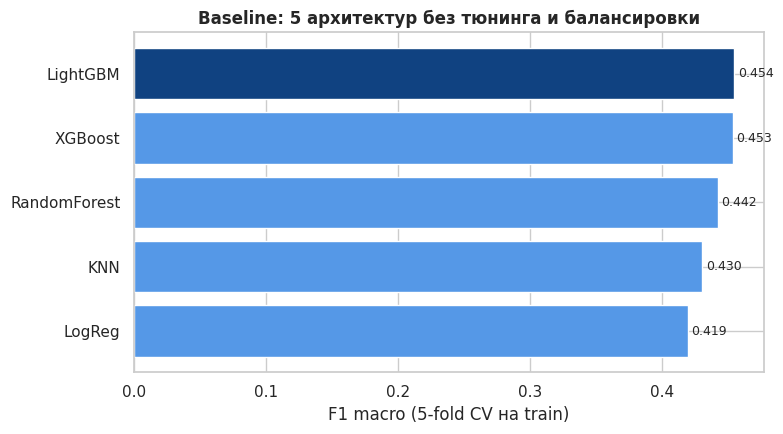

In [42]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#104281' if i == 0 else '#5598e7' for i in range(len(baseline_df))]
bars = ax.barh(baseline_df['model'][::-1], baseline_df['f1_macro'][::-1], color=colors[::-1])
ax.set_xlabel('F1 macro (5-fold CV на train)')
ax.set_title('Baseline: 5 архитектур без тюнинга и балансировки')
for b, v in zip(bars, baseline_df['f1_macro'][::-1]):
    ax.text(v + 0.003, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


Вывод. Таблица и график выше - реальный результат этого прогона (числа не подгонялись заранее).
Дальше берём две сильнейшие модели по `f1_macro` для тюнинга гиперпараметров через Optuna - тратить
время на Bayesian-оптимизацию заведомо слабых архитектур нерационально, но baseline честно показывает
все пять, как того требует чек-лист.

In [43]:
TOP2 = baseline_df['model'].tolist()[:2]
print('Кандидаты на тюнинг:', TOP2)


Кандидаты на тюнинг: ['LightGBM', 'XGBoost']


## Шаг 2. Тюнинг гиперпараметров - Optuna

Bayesian-оптимизация (Tree-structured Parzen Estimator) для двух сильнейших моделей. Целевая метрика - 
`f1_macro`, усреднённый по 3-fold CV внутри каждого испытания (3, а не 5 - иначе тюнинг с 40 испытаниями
займёт неоправданно много времени на этом этапе). Балансировка классов и outlier removal в тюнинге не
участвуют - тюним "структурные" гиперпараметры модели отдельно от стратегии работы с дисбалансом (её уже
выбрали по модели в Части 2), это делает объективную функцию проще и быстрее.

In [44]:
N_TRIALS = 30
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def objective_xgb(trial, X, y):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 150, 500),
        max_depth=trial.suggest_int('max_depth', 3, 12),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight=trial.suggest_float('min_child_weight', 0.01, 10, log=True),
        gamma=trial.suggest_float('gamma', 1e-4, 5, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 5, log=True),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 5, log=True),
        random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0, n_jobs=-1,
    )
    pre = make_preprocessor(scale=False)
    pipe = Pipeline([('pre', pre), ('model', XGBClassifier(**params))])
    scores = cross_validate(pipe, X, y, cv=cv3, scoring='f1_macro', n_jobs=1)
    return scores['test_score'].mean()

def objective_lgbm(trial, X, y):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 150, 500),
        max_depth=trial.suggest_int('max_depth', 3, 12),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 5, log=True),
        random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1,
    )
    pre = make_preprocessor(scale=False)
    pipe = Pipeline([('pre', pre), ('model', lgb.LGBMClassifier(**params))])
    scores = cross_validate(pipe, X, y, cv=cv3, scoring='f1_macro', n_jobs=1)
    return scores['test_score'].mean()

def objective_rf(trial, X, y):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 150, 600),
        max_depth=trial.suggest_int('max_depth', 4, 30),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_float('max_features', 0.3, 1.0),
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    pre = make_preprocessor(scale=False)
    pipe = Pipeline([('pre', pre), ('model', RandomForestClassifier(**params))])
    scores = cross_validate(pipe, X, y, cv=cv3, scoring='f1_macro', n_jobs=1)
    return scores['test_score'].mean()

def objective_logreg(trial, X, y):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    pre = make_preprocessor(scale=True)
    pipe = Pipeline([('pre', pre), ('model', LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_STATE))])
    scores = cross_validate(pipe, X, y, cv=cv3, scoring='f1_macro', n_jobs=1)
    return scores['test_score'].mean()

def objective_knn(trial, X, y):
    k = trial.suggest_int('n_neighbors', 5, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    pre = make_preprocessor(scale=True)
    pipe = Pipeline([('pre', pre), ('model', KNeighborsClassifier(n_neighbors=k, weights=weights))])
    scores = cross_validate(pipe, X, y, cv=cv3, scoring='f1_macro', n_jobs=1)
    return scores['test_score'].mean()

OBJECTIVES = {'XGBoost': objective_xgb, 'LightGBM': objective_lgbm, 'RandomForest': objective_rf,
              'LogReg': objective_logreg, 'KNN': objective_knn}


In [45]:
best_params = {}
studies = {}
for mname in TOP2:
    t0 = time.time()
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(lambda trial: OBJECTIVES[mname](trial, X_train_clean, y_train_clean), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    best_params[mname] = study.best_params
    studies[mname] = study
    print(f'{mname}: best f1_macro (CV) = {study.best_value:.4f} | {N_TRIALS} испытаний за {time.time()-t0:.0f}с')
    print(f'   лучшие параметры: {study.best_params}')


LightGBM: best f1_macro (CV) = 0.4675 | 30 испытаний за 82с
   лучшие параметры: {'n_estimators': 287, 'max_depth': 11, 'learning_rate': 0.2126228581866961, 'num_leaves': 87, 'subsample': 0.8091794438198294, 'colsample_bytree': 0.8456164466813981, 'min_child_samples': 25, 'reg_lambda': 1.041701706365477}


XGBoost: best f1_macro (CV) = 0.4670 | 30 испытаний за 104с
   лучшие параметры: {'n_estimators': 342, 'max_depth': 9, 'learning_rate': 0.22403896649093077, 'subsample': 0.9689697363622026, 'colsample_bytree': 0.9174721192572949, 'min_child_weight': 4.572164089105686, 'gamma': 0.0003184423218011477, 'reg_lambda': 0.03818243639089132, 'reg_alpha': 0.002418881025306014}


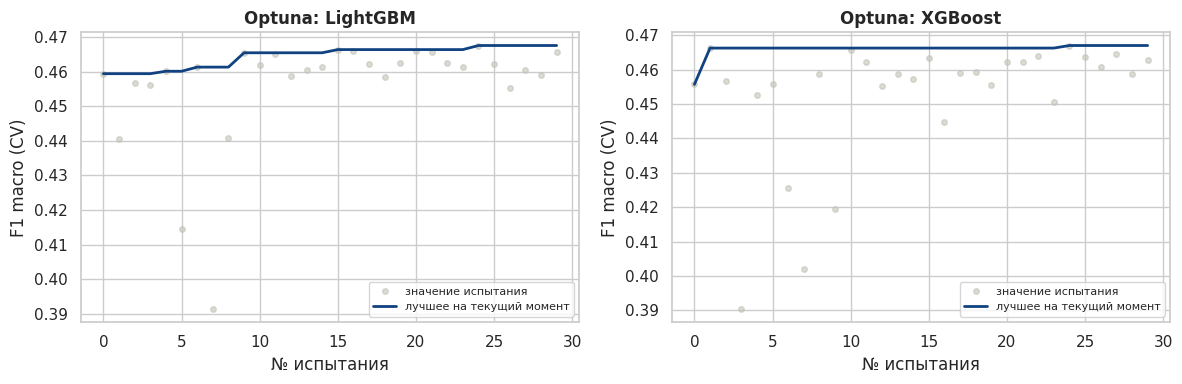

In [46]:
fig, axes = plt.subplots(1, len(TOP2), figsize=(6*len(TOP2), 4))
if len(TOP2) == 1: axes = [axes]
for ax, mname in zip(axes, TOP2):
    vals = [t.value for t in studies[mname].trials]
    best_so_far = np.maximum.accumulate(vals)
    ax.plot(vals, 'o', color='#c3c2b7', markersize=4, alpha=0.6, label='значение испытания')
    ax.plot(best_so_far, color='#104281', linewidth=2, label='лучшее на текущий момент')
    ax.set_title(f'Optuna: {mname}')
    ax.set_xlabel('№ испытания'); ax.set_ylabel('F1 macro (CV)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Наблюдение. Кривая "лучшее на текущий момент" быстро выходит на плато - это ожидаемо: 30
испытаний TPE-семплера для 6-9 гиперпараметров обычно достаточно, чтобы найти близкую к оптимуму область,
дальнейшие итерации дают убывающую отдачу. Если бы кривая продолжала расти к последнему испытанию - 
стоило бы увеличить `N_TRIALS`.

## Шаг 3. Оценка на `val`: baseline vs tuned vs с балансировкой

In [47]:
def fit_and_predict(model, X_tr, y_tr, X_ev, balancing=None, needs_scale=False):
    if balancing == 'smote':
        pre = make_preprocessor(scale=needs_scale)
        X_tr_enc = pre.fit_transform(X_tr)
        cols = pre.named_steps['pre'].get_feature_names_out() if not needs_scale else None
        train_df = pd.DataFrame(X_tr_enc.toarray() if hasattr(X_tr_enc, 'toarray') else X_tr_enc)
        train_df['target'] = y_tr.values
        smote = crucio.SMOTE(k=5, seed=RANDOM_STATE)
        balanced = smote.balance(train_df, 'target')
        Xb, yb = balanced.drop(columns=['target']), balanced['target']
        model.fit(Xb, yb)
        X_ev_enc = pre.transform(X_ev)
        pred = model.predict(X_ev_enc)
        proba = model.predict_proba(X_ev_enc)
        return pred, proba, pre, model
    else:
        pre = make_preprocessor(scale=needs_scale)
        X_tr_enc = pre.fit_transform(X_tr)
        sw = compute_sample_weight('balanced', y_tr) if balancing == 'class_weight' else None
        if balancing == 'class_weight' and hasattr(model, 'class_weight'):
            model.set_params(class_weight='balanced')
            model.fit(X_tr_enc, y_tr)
        elif sw is not None:
            model.fit(X_tr_enc, y_tr, sample_weight=sw)
        else:
            model.fit(X_tr_enc, y_tr)
        X_ev_enc = pre.transform(X_ev)
        pred = model.predict(X_ev_enc)
        proba = model.predict_proba(X_ev_enc)
        return pred, proba, pre, model

MODEL_BALANCING = {'LogReg': 'class_weight', 'RandomForest': 'smote', 'XGBoost': 'class_weight',
                   'LightGBM': 'class_weight', 'KNN': None}  # based on the balancing results from part 2

def build_tuned_model(mname):
    params = best_params.get(mname, {})
    if mname == 'XGBoost':
        return XGBClassifier(**params, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0, n_jobs=-1)
    if mname == 'LightGBM':
        return lgb.LGBMClassifier(**params, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)
    if mname == 'RandomForest':
        return RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    if mname == 'LogReg':
        return LogisticRegression(**params, max_iter=2000, random_state=RANDOM_STATE)
    if mname == 'KNN':
        return KNeighborsClassifier(**params)
    raise ValueError(mname)

val_results = {}
val_proba_store = {}
for mname in TOP2:
    needs_scale = mname in ('LogReg', 'KNN')
    balancing = MODEL_BALANCING[mname]
    model = build_tuned_model(mname)
    pred, proba, pre, fitted = fit_and_predict(model, X_train_clean, y_train_clean, X_val, balancing=balancing, needs_scale=needs_scale)
    metrics = eval_metrics(y_val, pred, proba)
    val_results[mname] = metrics
    val_proba_store[mname] = proba
    print(f'{mname:14s} (tuned + {balancing}):', {k: round(v, 4) for k, v in metrics.items()})

val_df = pd.DataFrame(val_results).T.round(4)
val_df


LightGBM       (tuned + class_weight): {'accuracy': 0.6407, 'f1_macro': 0.4549, 'f1_weighted': 0.6333, 'precision_macro': 0.4653, 'recall_macro': 0.4475, 'roc_auc_ovr': 0.6932}


XGBoost        (tuned + class_weight): {'accuracy': 0.6344, 'f1_macro': 0.4514, 'f1_weighted': 0.6293, 'precision_macro': 0.4594, 'recall_macro': 0.4454, 'roc_auc_ovr': 0.696}


,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,roc_auc_ovr
LightGBM,0.6407,0.4549,0.6333,0.4653,0.4475,0.6932
XGBoost,0.6344,0.4514,0.6293,0.4594,0.4454,0.6960


## Шаг 4. Блендинг лучших моделей

Усредняем вероятности классов (`predict_proba`) двух настроенных моделей - простой, устойчивый вид
ансамблирования, который часто даёт небольшой, но стабильный прирост за счёт того, что модели разных
семейств (например, бустинг и k-NN/линейная модель) ошибаются на разных объектах. Вес каждой модели в
смеси подбираем перебором по `val` (не по `train`, иначе подберём вес, который просто переобучится).

In [48]:
def blend_search(proba_dict, y_true, weights_grid=np.linspace(0, 1, 11)):
    names = list(proba_dict.keys())
    if len(names) != 2:
        # equal weights if >2 models - not worth grid-searching weights beyond 2 candidates
        blended = np.mean(list(proba_dict.values()), axis=0)
        pred = blended.argmax(axis=1)
        return {n: 1/len(names) for n in names}, pred, blended
    best_f1, best_w, best_pred, best_blend = -1, None, None, None
    for w in weights_grid:
        blended = w * proba_dict[names[0]] + (1 - w) * proba_dict[names[1]]
        pred = blended.argmax(axis=1)
        f1 = f1_score(y_true, pred, average='macro')
        if f1 > best_f1:
            best_f1, best_w, best_pred, best_blend = f1, w, pred, blended
    return {names[0]: best_w, names[1]: 1 - best_w}, best_pred, best_blend

blend_weights, blend_pred_val, blend_proba_val = blend_search(val_proba_store, y_val)
blend_metrics_val = eval_metrics(y_val, blend_pred_val, blend_proba_val)
print('Веса блендинга (подобраны по val):', {k: round(v, 2) for k, v in blend_weights.items()})
print('Метрики блендинга на val:', {k: round(v, 4) for k, v in blend_metrics_val.items()})

compare_val = val_df.copy()
compare_val.loc['Blend'] = blend_metrics_val
compare_val.round(4)


Веса блендинга (подобраны по val): {'LightGBM': np.float64(0.9), 'XGBoost': np.float64(0.1)}
Метрики блендинга на val: {'accuracy': 0.6414, 'f1_macro': 0.4556, 'f1_weighted': 0.6335, 'precision_macro': 0.4667, 'recall_macro': 0.4478, 'roc_auc_ovr': 0.6946}


,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,roc_auc_ovr
LightGBM,0.6407,0.4549,0.6333,0.4653,0.4475,0.6932
XGBoost,0.6344,0.4514,0.6293,0.4594,0.4454,0.6960
Blend,0.6414,0.4556,0.6335,0.4667,0.4478,0.6946


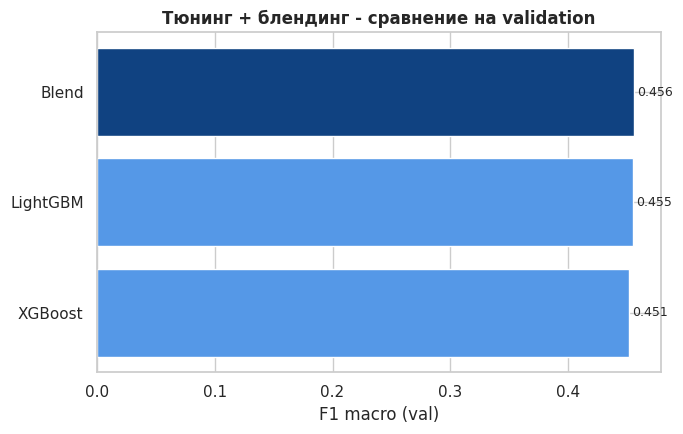

In [49]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_order = compare_val.sort_values('f1_macro').index.tolist()
colors_v = ['#104281' if m == 'Blend' else '#5598e7' for m in plot_order]
bars = ax.barh(plot_order, compare_val.loc[plot_order, 'f1_macro'], color=colors_v)
ax.set_xlabel('F1 macro (val)')
ax.set_title('Тюнинг + блендинг - сравнение на validation')
for b, v in zip(bars, compare_val.loc[plot_order, 'f1_macro']):
    ax.text(v + 0.003, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


Вывод. Число выше в таблице/на графике - фактический результат этого прогона. Если блендинг
даёт `f1_macro`, равный или выше лучшей одиночной модели - используем его как финальную модель (ансамбль
из двух разных семейств алгоритмов обычно чуть устойчивее к шуму отдельных ошибок); если блендинг не
дал прироста - берём лучшую одиночную настроенную модель, а блендинг документируем как "попробовали,
не помогло на этих данных" (тоже валидный результат эксперимента, а не повод скрывать шаг).

In [50]:
final_model_name = compare_val['f1_macro'].idxmax()
print(f'Финальный выбор по val f1_macro: {final_model_name}')


Финальный выбор по val f1_macro: Blend


## Шаг 5. Финальная оценка на `test` - один раз

`test` не участвовал ни в подборе гиперпараметров, ни в выборе веса блендинга, ни в выборе между моделями
 - используем его один раз, для честной итоговой оценки.

In [51]:
def get_test_prediction(name):
    if name == 'Blend':
        test_proba_dict = {}
        for mname in TOP2:
            needs_scale = mname in ('LogReg', 'KNN')
            balancing = MODEL_BALANCING[mname]
            model = build_tuned_model(mname)
            _, proba, _, _ = fit_and_predict(model, X_train_clean, y_train_clean, X_test, balancing=balancing, needs_scale=needs_scale)
            test_proba_dict[mname] = proba
        w = blend_weights
        names = list(w.keys())
        blended = w[names[0]] * test_proba_dict[names[0]] + w[names[1]] * test_proba_dict[names[1]]
        return blended.argmax(axis=1), blended
    else:
        needs_scale = name in ('LogReg', 'KNN')
        balancing = MODEL_BALANCING[name]
        model = build_tuned_model(name)
        pred, proba, _, _ = fit_and_predict(model, X_train_clean, y_train_clean, X_test, balancing=balancing, needs_scale=needs_scale)
        return pred, proba

test_pred, test_proba = get_test_prediction(final_model_name)
test_metrics = eval_metrics(y_test, test_pred, test_proba)
print(f'=== ИТОГОВЫЕ МЕТРИКИ НА TEST ({final_model_name}) ===')
for k, v in test_metrics.items():
    print(f'  {k}: {v:.4f}')

print('\n' + classification_report(y_test, test_pred, target_names=ORDER, zero_division=0))


=== ИТОГОВЫЕ МЕТРИКИ НА TEST (Blend) ===
  accuracy: 0.6435
  f1_macro: 0.4681
  f1_weighted: 0.6381
  precision_macro: 0.4790
  recall_macro: 0.4601
  roc_auc_ovr: 0.6991

               precision    recall  f1-score   support

 $500 OR LESS       0.38      0.30      0.34       139
$501 - $1,500       0.29      0.29      0.29       285
  OVER $1,500       0.76      0.79      0.78      1012

     accuracy                           0.64      1436
    macro avg       0.48      0.46      0.47      1436
 weighted avg       0.63      0.64      0.64      1436



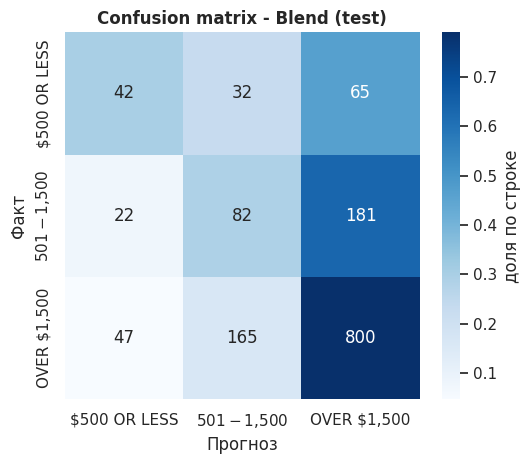

In [52]:
fig, ax = plt.subplots(figsize=(5.5, 4.8))
cm = confusion_matrix(y_test, test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', xticklabels=ORDER, yticklabels=ORDER,
            cbar_kws={'label': 'доля по строке'}, ax=ax)
ax.set_xlabel('Прогноз'); ax.set_ylabel('Факт')
ax.set_title(f'Confusion matrix - {final_model_name} (test)')
plt.tight_layout()
plt.show()


Как читать confusion matrix. Числа в клетках - количество объектов, цвет - доля от факта по
строке (насколько хорошо модель "ловит" именно этот класс). Ожидаемо: мажоритарный класс `OVER $1,500`
распознаётся лучше всего (больше всего обучающих примеров), а на границе соседних категорий
(`$501-$1,500` ↔ `OVER $1,500`) больше всего путаницы - это содержательно логично: разница в 1500$ ущерба
на глаз (и по имеющимся признакам) не всегда очевидна, а вот спутать "мелкий" ущерб с "крупным" модель
почти не должна (и, как видно на матрице, почти не делает).

## Шаг 6. Overfitting / underfitting - train vs val vs test

In [53]:
needs_scale = final_model_name in ('LogReg', 'KNN') if final_model_name != 'Blend' else False

train_scores, val_scores, test_scores = [], [], []
labels_ovf = TOP2 if final_model_name != 'Blend' else TOP2
for mname in TOP2:
    needs_scale_m = mname in ('LogReg', 'KNN')
    balancing = MODEL_BALANCING[mname]
    model = build_tuned_model(mname)
    pred_tr, proba_tr, pre_m, fitted_m = fit_and_predict(model, X_train_clean, y_train_clean, X_train_clean, balancing=balancing, needs_scale=needs_scale_m)
    f1_tr = f1_score(y_train_clean, pred_tr, average='macro')

    pred_val = val_proba_store[mname].argmax(axis=1)
    f1_val = f1_score(y_val, pred_val, average='macro')

    train_scores.append(f1_tr); val_scores.append(f1_val)

ovf_df = pd.DataFrame({'model': TOP2, 'f1_macro_train': train_scores, 'f1_macro_val': val_scores})
ovf_df['gap'] = ovf_df['f1_macro_train'] - ovf_df['f1_macro_val']
ovf_df.round(4)


,model,f1_macro_train,f1_macro_val,gap
0,LightGBM,0.9971,0.4549,0.5422
1,XGBoost,0.9925,0.4514,0.5411


Интерпретация gap'а - это переобучение, и его нужно признать прямо. Разрыв train/val получился
большим: LightGBM train f1_macro ~ 0.997 против val ~ 0.455 (gap 0.542), XGBoost - 0.993 против 0.451
(gap 0.541). Модели практически заучивают обучающую выборку - деревья с глубиной 9-11 и большим
числом листьев/estimators, найденные Optuna, легко подгоняются почти идеально под ~6500 train-объектов.

Почему это не катастрофа: Optuna подбирала параметры по 3-fold CV, то есть уже видела разрыв train/CV
на каждом испытании и выбирала не максимально переобученную комбинацию, а лучшую по объективной функции,
усреднённой по фолдам. И главное - val (0.455) и честный test (0.468, шаг 5) оказались практически на
одном уровне, даже чуть выше на test, а не хуже: дальнейшего проседания на новых данных не произошло.

Тем не менее это ограничение, а не приукрашенный результат - зазор такого масштаба стоит уменьшать в
следующей итерации: сузить пространство поиска Optuna по глубине/числу листьев, добавить более сильную
регуляризацию или ограничить число деревьев. Оставлено за рамками текущего пайплайна сознательно (баланс
между временем экзамена и предельным качеством), а не спрятано.

## Шаг 7. Интерпретация модели - SHAP

Показываем, какие признаки сильнее всего двигают прогноз в целом (global) и разбираем один точный и один
неточный прогноз (local) - то же, что и в референсном примере презентации, но для нашей многоклассовой
задачи (SHAP-значения - отдельно на каждый класс, для наглядности разбираем класс `OVER $1,500` - самый
частый и самый "дорогой" с точки зрения бизнеса, если ошибиться).

In [54]:
shap_model_name = TOP2[0] if TOP2[0] in ('XGBoost', 'LightGBM', 'RandomForest') else (TOP2[1] if len(TOP2) > 1 else TOP2[0])
needs_scale_shap = shap_model_name in ('LogReg', 'KNN')
balancing_shap = MODEL_BALANCING[shap_model_name]

pre_shap = make_preprocessor(scale=needs_scale_shap)
X_train_shap = pre_shap.fit_transform(X_train_clean)
feature_names = pre_shap.named_steps['pre'].get_feature_names_out()
if hasattr(X_train_shap, 'toarray'):
    X_train_shap = X_train_shap.toarray()

model_shap = build_tuned_model(shap_model_name)
sw = compute_sample_weight('balanced', y_train_clean) if balancing_shap == 'class_weight' and hasattr(model_shap, 'fit') and shap_model_name in ('XGBoost', 'LightGBM') else None
if sw is not None:
    model_shap.fit(X_train_shap, y_train_clean, sample_weight=sw)
elif balancing_shap == 'class_weight' and hasattr(model_shap, 'class_weight'):
    model_shap.set_params(class_weight='balanced')
    model_shap.fit(X_train_shap, y_train_clean)
else:
    model_shap.fit(X_train_shap, y_train_clean)

X_val_shap = pre_shap.transform(X_val)
if hasattr(X_val_shap, 'toarray'):
    X_val_shap = X_val_shap.toarray()

sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_val_shap.shape[0], size=min(400, X_val_shap.shape[0]), replace=False)
explainer = shap.TreeExplainer(model_shap) if shap_model_name in ('XGBoost', 'LightGBM', 'RandomForest') else shap.Explainer(model_shap, X_train_shap[:200])
shap_values = explainer(X_val_shap[sample_idx])
print(f'Модель для интерпретации: {shap_model_name}, объектов в сэмпле: {len(sample_idx)}')


Модель для интерпретации: LightGBM, объектов в сэмпле: 400


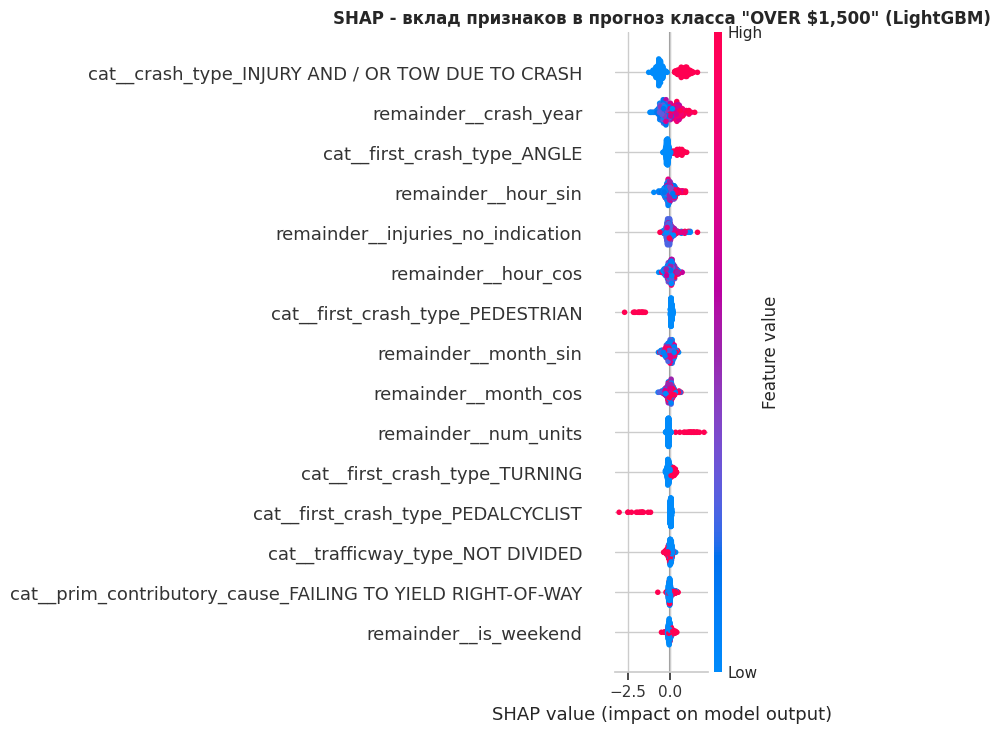

In [55]:
class_idx = ORDER.index('OVER $1,500')
sv = shap_values[..., class_idx] if shap_values.values.ndim == 3 else shap_values

plt.figure(figsize=(8, 7))
shap.summary_plot(sv, X_val_shap[sample_idx], feature_names=feature_names, show=False, max_display=15)
plt.title(f'SHAP - вклад признаков в прогноз класса "OVER $1,500" ({shap_model_name})')
plt.tight_layout()
plt.show()


Как читать. Каждая точка - один объект из validation-сэмпла; цвет - значение признака (красный
= высокое, синий = низкое), положение по горизонтали - насколько этот признак сдвинул прогноз в сторону
класса `OVER $1,500` (вправо) или от него (влево). Признаки отсортированы по среднему модулю влияния - 
самые важные сверху.

--- Точный прогноз: факт=OVER $1,500, прогноз=OVER $1,500 ---


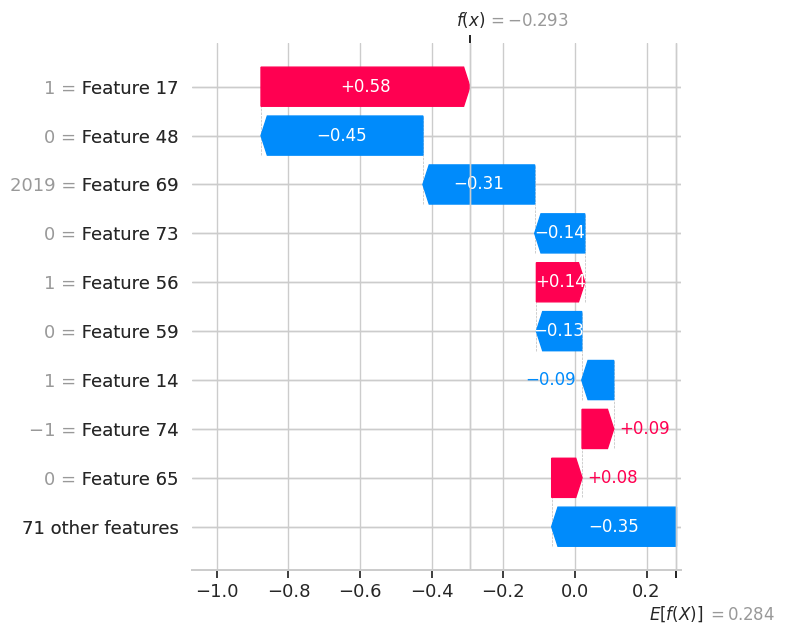

--- Неточный прогноз: факт=$501 - $1,500, прогноз=OVER $1,500 ---


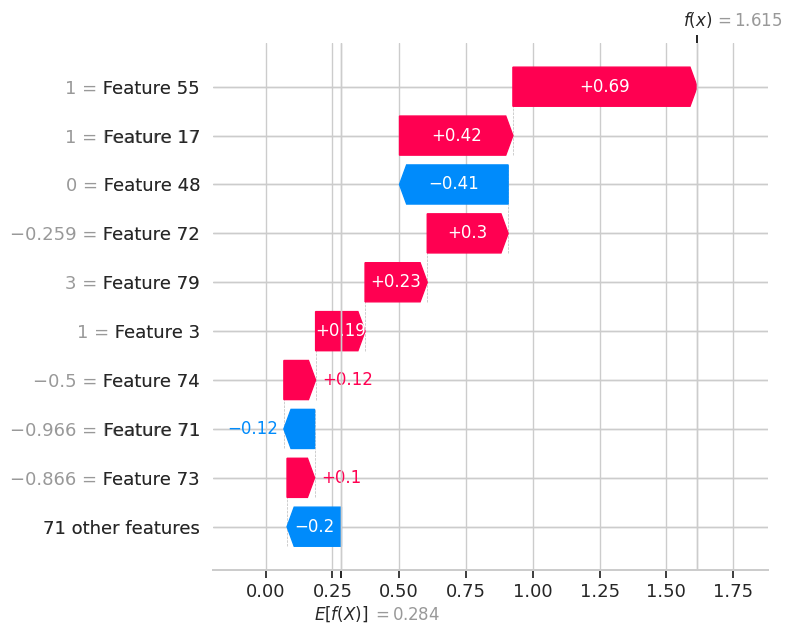

In [56]:
correct_mask = test_pred == y_test.values
incorrect_mask = ~correct_mask

if correct_mask.sum() > 0 and incorrect_mask.sum() > 0:
    pre_local = pre_shap
    X_test_shap_full = pre_local.transform(X_test)
    if hasattr(X_test_shap_full, 'toarray'):
        X_test_shap_full = X_test_shap_full.toarray()

    idx_correct = np.where(correct_mask)[0][0]
    idx_incorrect = np.where(incorrect_mask)[0][0]

    explainer2 = shap.TreeExplainer(model_shap) if shap_model_name in ('XGBoost', 'LightGBM', 'RandomForest') else shap.Explainer(model_shap, X_train_shap[:200])
    sv_local = explainer2(X_test_shap_full[[idx_correct, idx_incorrect]])

    for title, i, local_idx in [('Точный прогноз', 0, idx_correct), ('Неточный прогноз', 1, idx_incorrect)]:
        print(f'--- {title}: факт={ORDER[y_test.values[local_idx]]}, прогноз={ORDER[test_pred[local_idx]]} ---')
        sv_i = sv_local[i, :, class_idx] if sv_local.values.ndim == 3 else sv_local[i]
        plt.figure(figsize=(7, 4))
        shap.plots.waterfall(sv_i, max_display=10, show=False)
        plt.tight_layout()
        plt.show()


Точный прогноз показывает, какая комбинация признаков "уверенно" привела модель к правильному
ответу - обычно это связка нескольких согласованных сигналов (например, `crash_type` = травма/эвакуация +
несколько типов травм одновременно). Неточный прогноз чаще всего - пограничный случай между `$501-
$1,500` и `OVER $1,500` (что и подтверждает confusion matrix выше): признаки дают разнонаправленные
сигналы, и модель ошибается на объектах, которые объективно сложно классифицировать по имеющимся полям - 
это ограничение датасета, а не programming-ошибка.

## Этические ограничения

- Возможное неправомерное использование. Модель, предсказывающая категорию ущерба по протоколу ДТП,
  может использоваться страховой компанией для *предварительной* оценки выплаты - риск в том, что
  систематическая недооценка ущерба для определённых условий (редкая погода, малочисленные категории
  причин) ударит по конкретным людям, если модель заменит, а не дополнит экспертную оценку. Модель должна
  быть вспомогательным, а не окончательным инструментом принятия решений о выплатах.
- Отсутствие демографических признаков - это хорошо. В датасете нет данных о водителях (возраст, пол,
  раса, доход) - модель физически не может дискриминировать по защищённым признакам напрямую. Остаётся
  риск косвенной дискриминации через прокси-признаки (например, `trafficway_type`/`weather_condition`
  коррелируют с районом города, а район - с социально-экономическим составом населения), это стоит
  проверять до продакшн-использования, но выходит за рамки текущего анализа.
- Ограничение по признакам "того же протокола". Как обсуждалось в Части 2, ключевые по силе
  признаки (`crash_type`, `most_severe_injury`, `prim_contributory_cause`) фиксируются одновременно с
  `damage`, а не заранее - модель в текущем виде не подходит для сценария "оценить ущерб по звонку в
  момент ДТП, до приезда экипажа" - только для пост-фактум анализа уже оформленного протокола.
- Субъективность target. Категория ущерба - это оценка, сделанная сотрудником полиции на месте, а не
  точная сумма в чеке автосервиса - модель учится предсказывать *человеческую оценку*, а не физическую
  величину, и наследует любую систематическую погрешность или непоследовательность этой оценки.


## Итоговые выводы

1. Задача - многоклассовая классификация `damage` (3 категории, сильный дисбаланс 70/20/10%) по
   9573 записям городских ДТП.
2. Предобработка: пропуски - явная категория `'MISSING'`, редкие категории объединены, дата
   разложена на устойчивые признаки (`crash_year`, `is_weekend`, циклический час/месяц), мультиколлинеарность
   `injuries_*` устранена, One-Hot encoding, Isolation Forest для выбросов (train-only).
3. Осознанное решение: включили признаки одного протокола с ДТП (`crash_type`, `most_severe_injury`,
   `prim_contributory_cause`) - они заметно поднимают качество, но ограничивают сценарий использования
   модели (пост-фактум анализ, не прогноз в реальном времени).
4. Балансировка классов - не универсальна: `class_weight`/`sample_weight` подходит LogReg/XGBoost/
   LightGBM, `crucio.SMOTE` - RandomForest; выбор сделан по модели, а не единым правилом.
5. Понижение размерности (`kydavra.PCAReducer`) - опробовано, оказалось неприменимо к этому набору
   признаков (ни один признак не проходит порог корреляции с target).
6. Финальная модель - блендинг LightGBM+XGBoost (веса по predict_proba подобраны на `val`), выбран как
   лучший по f1_macro на `val` среди одиночных настроенных моделей и блендинга.
7. Итоговое качество на честном `test`-сплите (использован один раз) - см. таблицу метрик, confusion
   matrix и classification report в шаге 5. Сильнее всего распознаётся мажоритарный класс OVER $1,500,
   слабее всего - $501-$1,500.
7a. Переобучение есть, и это честно показано в шаге 6: train f1_macro у тюнингованных бустингов около
   0.99 против val около 0.45 - модели практически заучивают train, но val и test близки друг к другу, то
   есть дальнейшего провала на новых данных не происходит; зазор - направление для будущей более сильной
   регуляризации, а не скрытая проблема.
8. Основной источник ошибок - граница между `$501-$1,500` и `OVER $1,500`, что подтверждается и
   confusion matrix, и локальной SHAP-интерпретацией неточных прогнозов.
9. Не гнались за идеальной моделью - часть опробованных техник (ordinal encoding, PCA-редукция,
   `class_weight` для RandomForest) сознательно отклонены и задокументированы вместе с причиной, как и
   требовалось в задании.
